# Xenium Breast 5K Medium Crop: cellAdmix Membrane Scoring

## Overview

This is a medium-crop version of the breast 5K membrane-scoring notebook, meant
for fast iteration on content, layout, and diagnostics before rerunning the full
dataset. The crop is large enough to contain both immune-rich and
tumor-epithelial domains, but much smaller than the full 82M-molecule dataset.

## Inputs and Crop

The annotation notebook writes `annotations/annotation.csv.gz` and
`annotations/domain_annotation.csv.gz`. We keep the same annotations here but
construct a cropped cellAdmix dataset using `analysis_bbox`.

For this 5K panel we use stricter cell-complexity thresholds in the annotation
and cell-state UMAP diagnostics: `min_molecules = 30` and `min_genes = 15`.
The lower defaults produced many small low-complexity UMAP islands in this
dataset.

In [ ]:
bundle_dir <- "data"
output_dir <- "out_medium_crop"
annotation_file <- file.path("annotations", "annotation.csv.gz")
domain_file <- file.path("annotations", "domain_annotation.csv.gz")
analysis_bbox <- c(5000, 7000, 4500, 6500)

annotation <- read.csv(annotation_file, stringsAsFactors = FALSE)
domain_annotation <- read.csv(domain_file, stringsAsFactors = FALSE)

in_crop <- annotation$cell_id %in% domain_annotation$cell_id[
  domain_annotation$x >= analysis_bbox[[1]] &
    domain_annotation$x <= analysis_bbox[[2]] &
    domain_annotation$y >= analysis_bbox[[3]] &
    domain_annotation$y <= analysis_bbox[[4]]
]
table(annotation$merged_annotation[in_crop])
table(domain_annotation$domain_label[
  domain_annotation$x >= analysis_bbox[[1]] &
    domain_annotation$x <= analysis_bbox[[2]] &
    domain_annotation$y >= analysis_bbox[[3]] &
    domain_annotation$y <= analysis_bbox[[4]]
])


Ambiguous / low-quality              B / plasma             Endothelial 
                   3133                    1498                     810 
             Epithelial        Fibroblast / CAF                 Myeloid 
                  14839                     648                    3499 
                 T / NK 
                   7085 


     immune_rich tumor_epithelial 
           20106            11406 

Cells labeled `Ambiguous / low-quality` are retained in side plots but excluded
from the active fit/scoring annotation.

In [ ]:
cell_annotation <- setNames(annotation$merged_annotation, annotation$cell_id)
cell_annotation <- cell_annotation[cell_annotation != "Ambiguous / low-quality"]

ds <- cellAdmix(bundle_dir, output_dir = output_dir, annotation = cell_annotation,
  num_threads = 10, analysis_bbox = analysis_bbox)

ds

cellAdmix dataset
  format: xenium 
  output cache: configured
  threads: 10 
  molecules: transcripts.parquet 
  cells: cells.parquet 
  annotation:manual (422675 cells, 6 labels)

## Fit Factors

The fit uses the `invsqrt_kl` NMF variant, the recommended pairing for
membrane scoring on stained data (see
[docs/benchmarks.md](../../docs/benchmarks.md)).

In [ ]:
fit <- ds$fit(nmf_variant = "invsqrt_kl", verbose = TRUE)

fit

Reusing cached run fit_manual_rank8_invsqrt_kl (parameters match)

cellAdmix fit
  run: fit_manual_rank8_invsqrt_kl 
  annotation: manual 
  rank: 8 
  NMF: invsqrt_kl 
  molecule scoring: gene_loadings 
  cells: 34541 
  transcripts: 8189365 

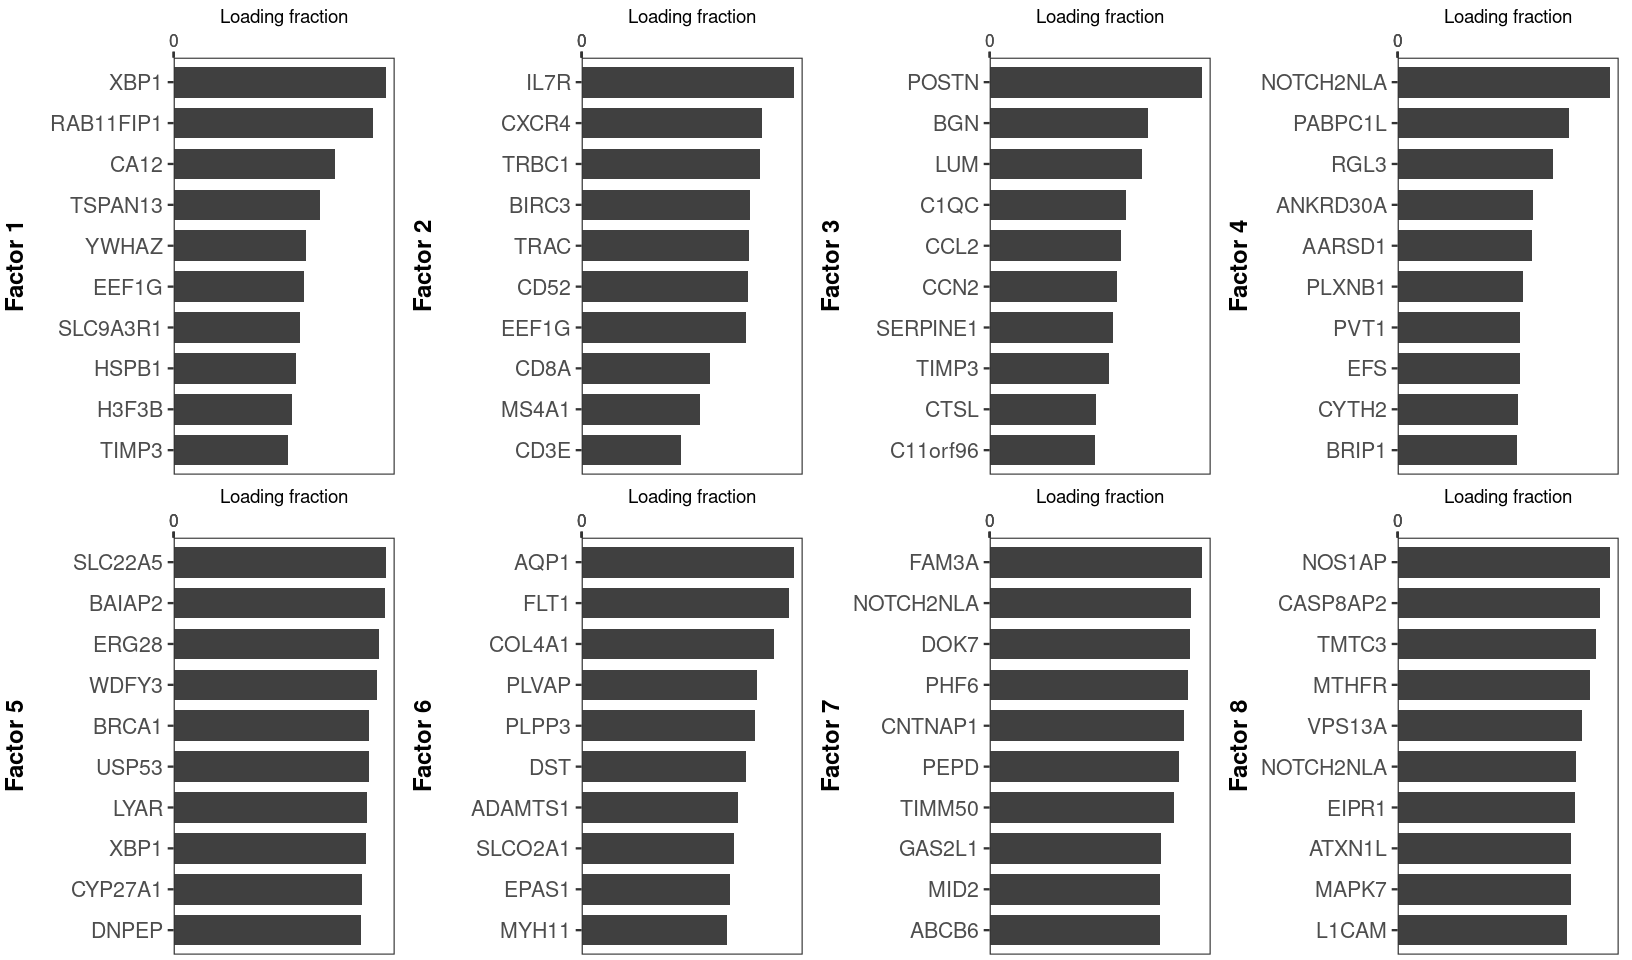

In [ ]:
fit$plot_loadings()

The stability plot shows the matched gene-ownership correlation of each factor
across independent NMF restarts (near zero for unrelated factors, above 0.3
for reproducibly re-found ones). Factor importance (the x-axis, echoed by dot size) is the share of all assigned molecules that carry the factor's label, so large dots mark factors that dominate the tissue-wide signal.

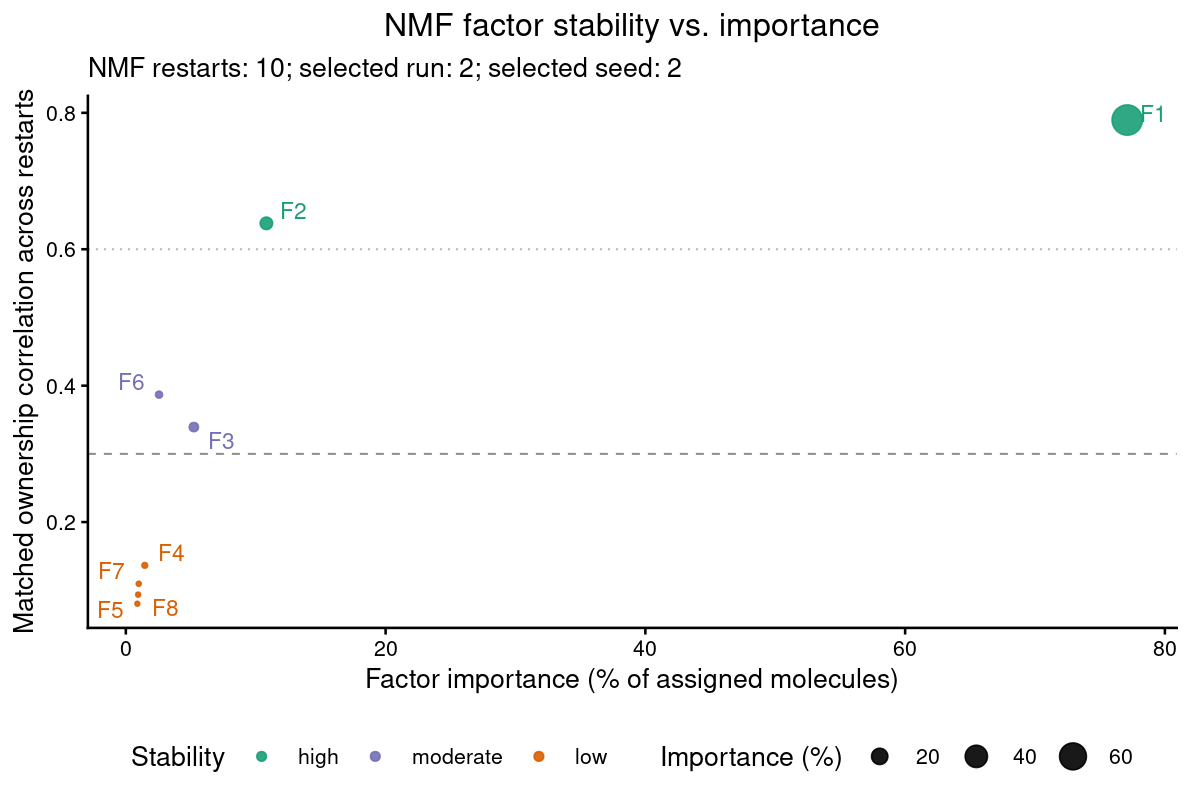

In [ ]:
fit$plot_stability()

## Admixture Audit

Before correcting anything, the audit estimates each ordered cell-type
pair's admixture rate within the crop — the percent of the target type's
molecules that leaked in from the source — using only the spatial
exposure structure of the data.

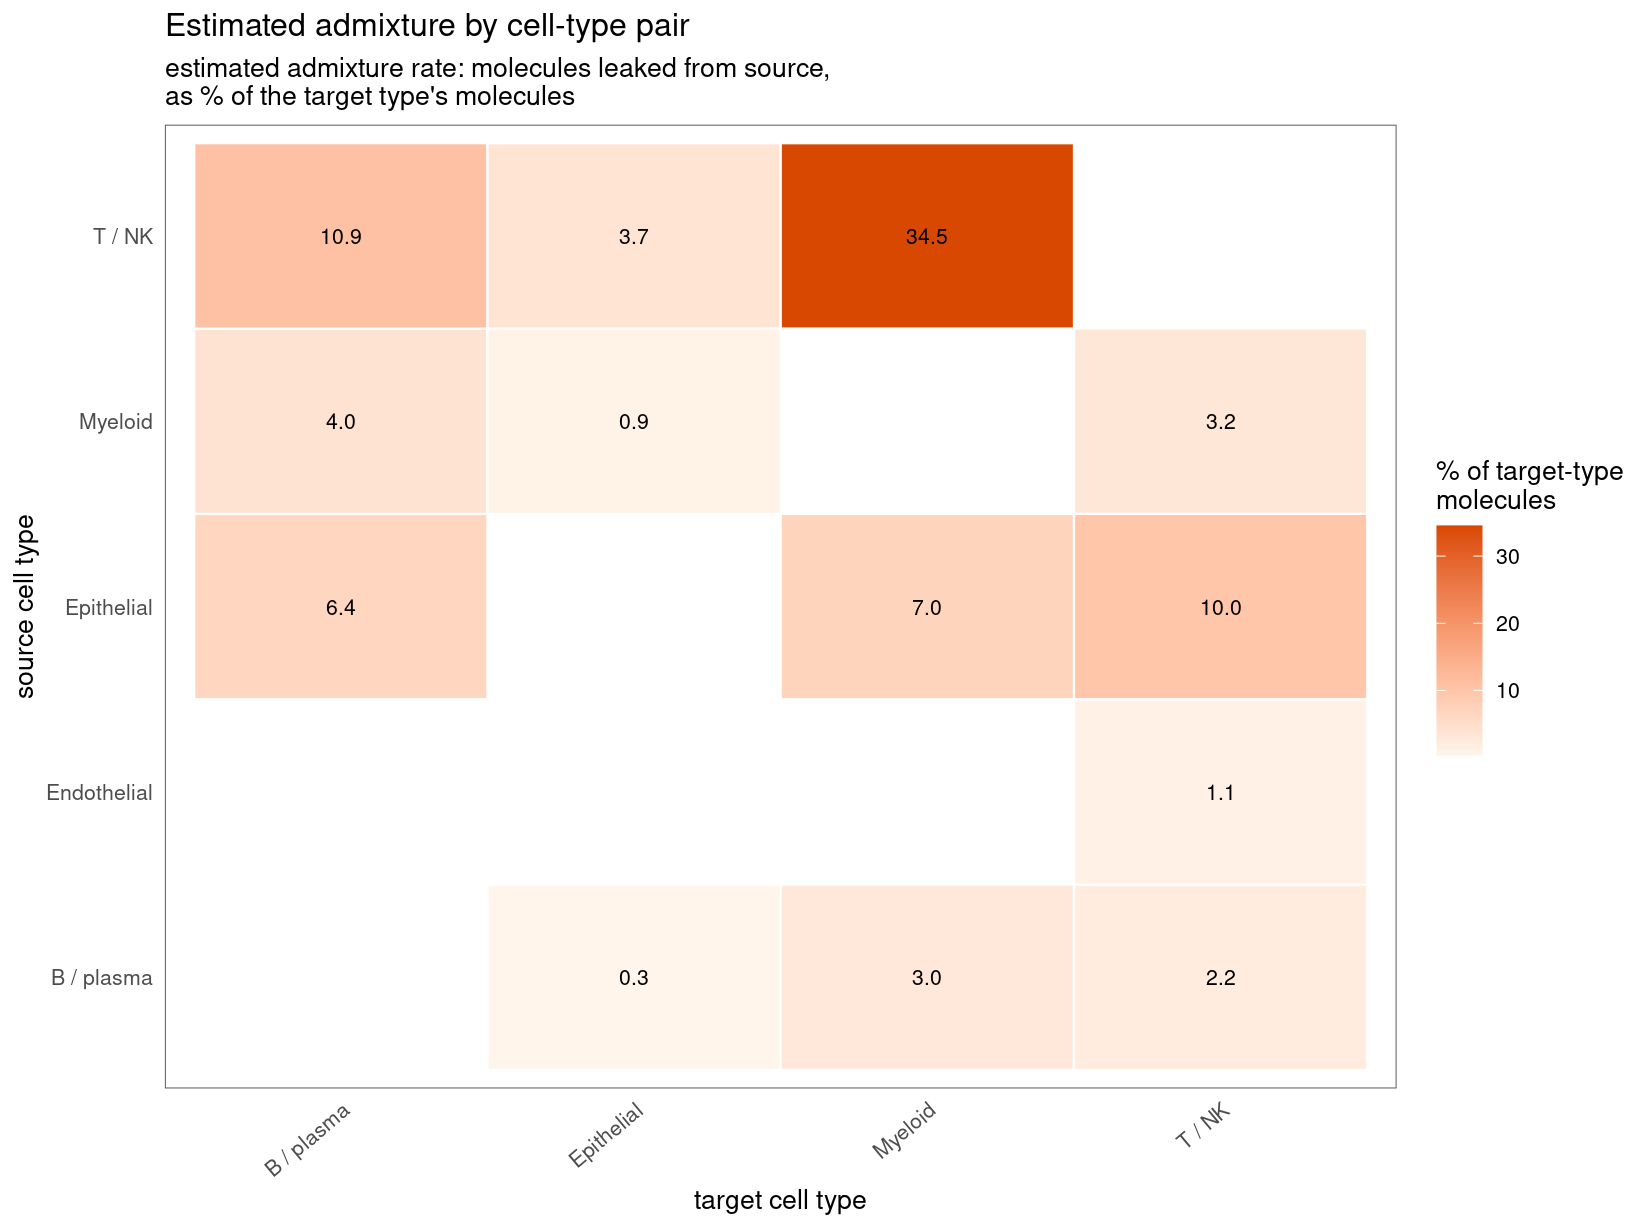

In [ ]:
audit <- fit$audit_admixture()
audit$plot_map()

## Tissue Context

In [ ]:
cell_factors <- fit$cell_factors()
cell_spatial <- merge(cell_factors,
  annotation[, c("cell_id", "merged_annotation", "cluster_label")],
  by = "cell_id", all.x = FALSE, sort = FALSE)
cell_spatial <- merge(cell_spatial,
  domain_annotation[, c("cell_id", "domain_label")],
  by = "cell_id", all.x = FALSE, sort = FALSE)
cell_spatial$domain_label <- factor(cell_spatial$domain_label,
  levels = c("immune_rich", "tumor_epithelial"))

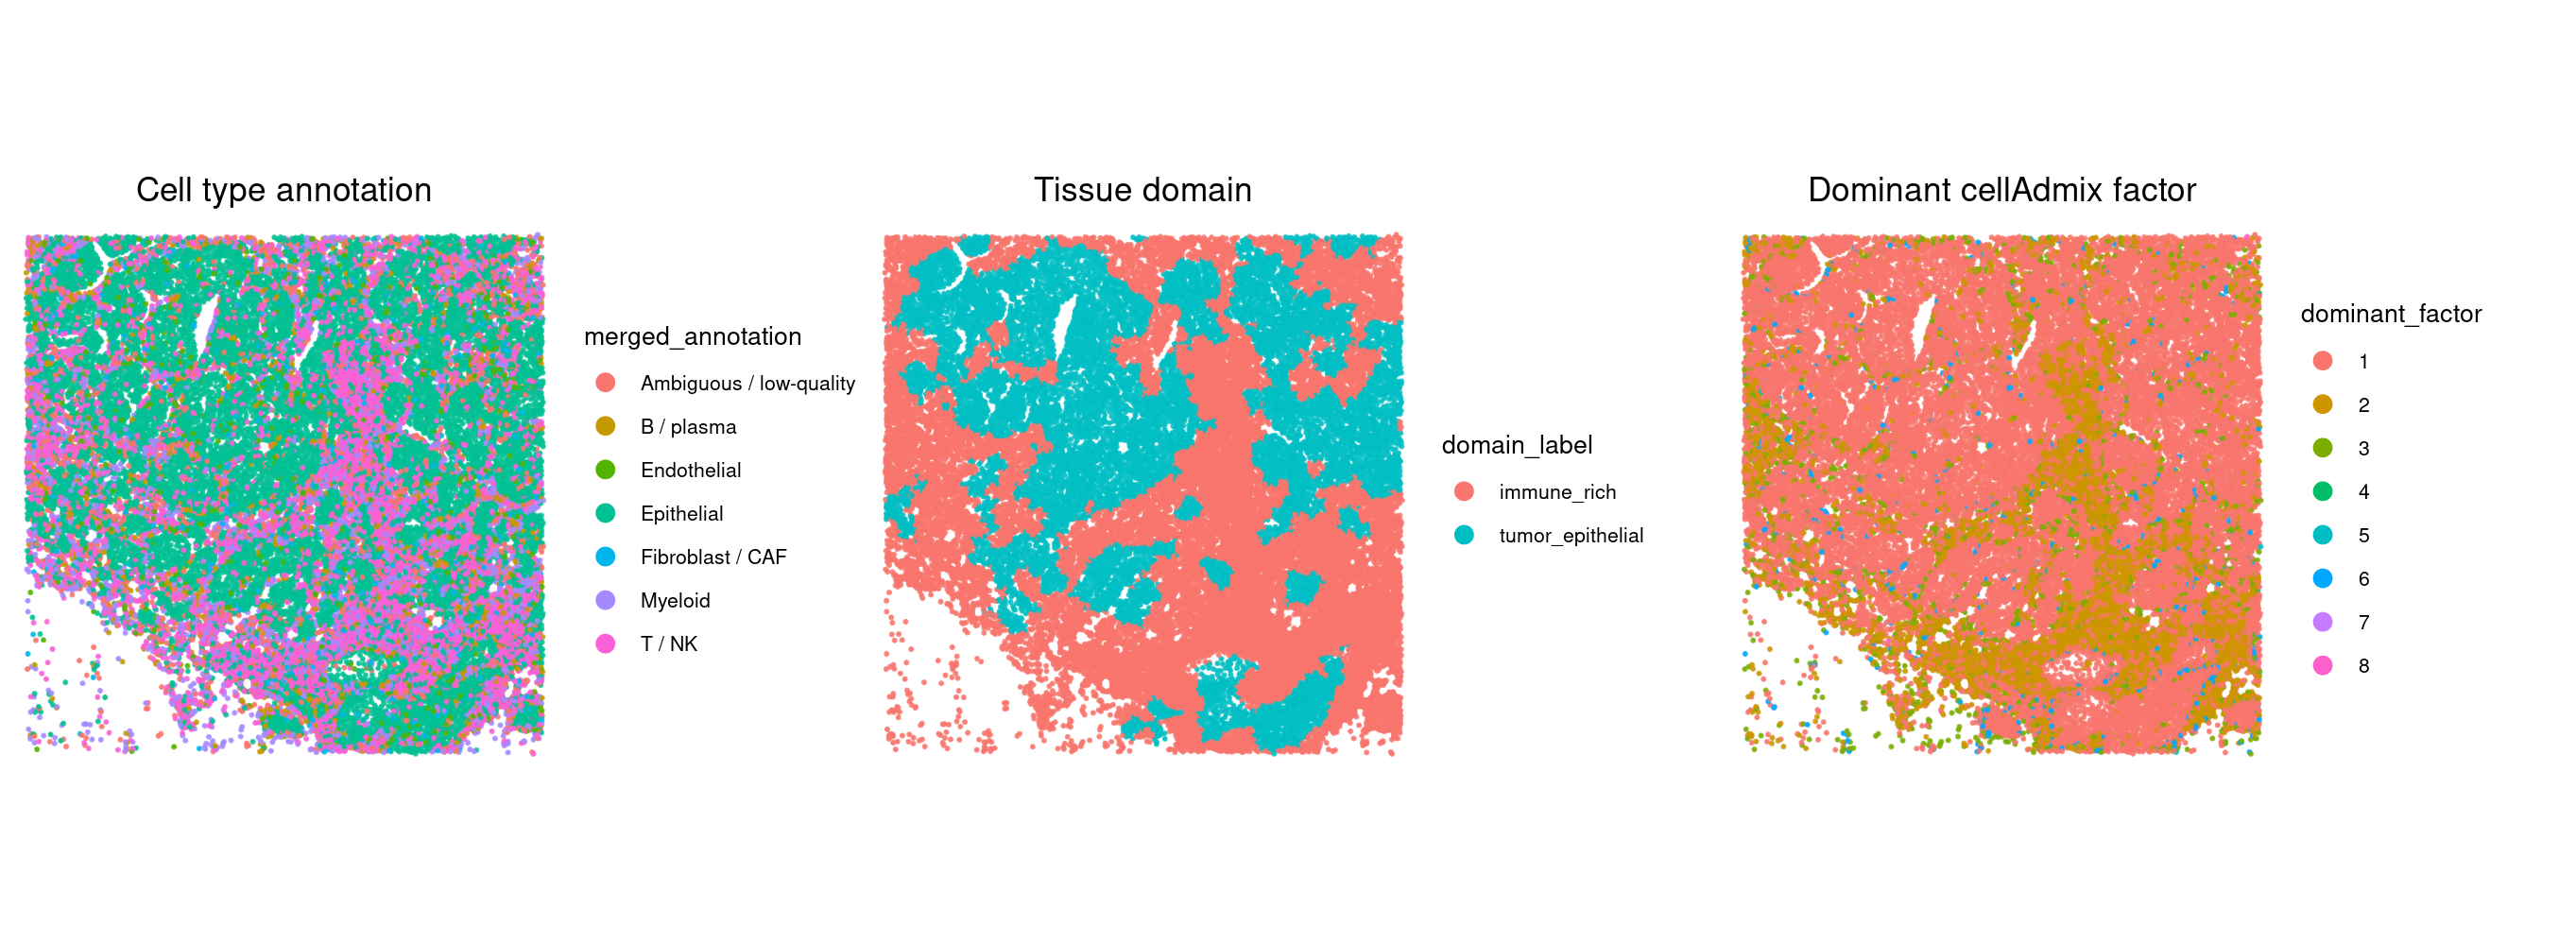

In [ ]:
cowplot::plot_grid(plotlist = list(
  celladmix_plot_spatial(cell_spatial, color_by = "merged_annotation",
    point_size = 0.18) +
    ggtitle("Cell type annotation"),
  celladmix_plot_spatial(cell_spatial, color_by = "domain_label",
    point_size = 0.18) +
    ggtitle("Tissue domain"),
  celladmix_plot_spatial(cell_spatial, color_by = "dominant_factor",
    point_size = 0.18) +
    ggtitle("Dominant cellAdmix factor")
), ncol = 3, align = "hv", axis = "tblr")

## Diagnostic Setup

In [ ]:
diagnostic_cell_types <- c("Fibroblast / CAF", "Endothelial")

epithelial_tumor_markers <- c("EPCAM", "KRT8", "KRT18", "KRT19", "MUC1",
  "GATA3", "CA12", "XBP1", "ERBB2")
lymphoid_myeloid_markers <- c("TRAC", "TRBC1", "CD3D", "CD3E", "CD8A",
  "IL7R", "MS4A1", "CD79A", "AIF1", "C1QC", "MS4A6A", "ITGAX")
source_marker_sets <- list(
  "epithelial/tumor source" = epithelial_tumor_markers,
  "immune source" = lymphoid_myeloid_markers
)

In [ ]:
original_counts <- fit$counts()
diagnostic_de_original <- celladmix_de_by_group(original_counts, cell_spatial,
  subset_by = "merged_annotation", subsets = diagnostic_cell_types,
  group_by = "domain_label", contrast = c("tumor_epithelial", "immune_rich"))

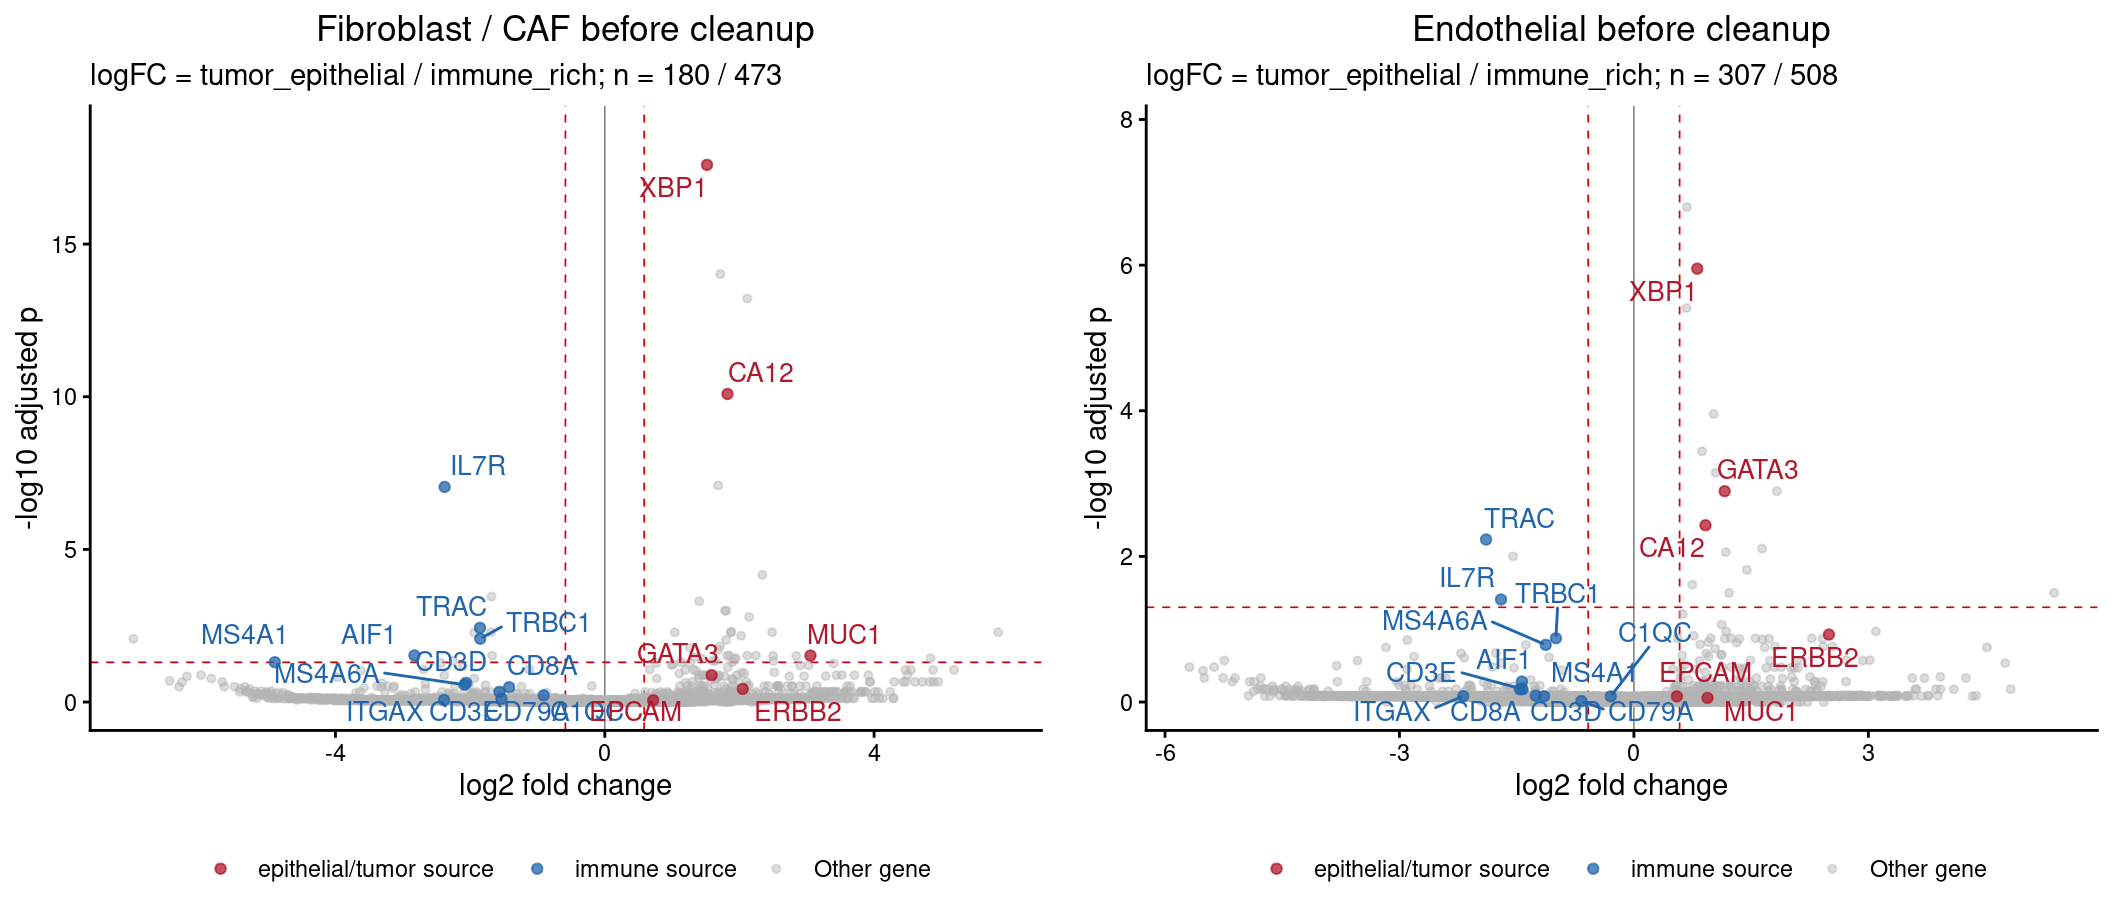

In [ ]:
baseline_volcano_plots <- lapply(diagnostic_cell_types, function(target_type) {
  de <- diagnostic_de_original[[target_type]]
  celladmix_plot_volcano(de, markers = source_marker_sets,
    title = paste(target_type, "before cleanup"),
    subtitle = sprintf("logFC = tumor_epithelial / immune_rich; n = %d / %d",
      unique(de$n_group_a), unique(de$n_group_b)))
})
cowplot::plot_grid(plotlist = baseline_volcano_plots,
  ncol = length(baseline_volcano_plots), align = "hv", axis = "tblr")

## Membrane Scoring

This crop is small enough that a permissive rule threshold can produce broad
cleanup calls. We use a stricter `p_thresh = 0.01` here to keep the exploratory
crop diagnostics interpretable before moving back to full-dataset settings.

In [ ]:
p_thresh <- 0.01
score_pairs_width <- 9.6
score_pairs_height <- max(6, ceiling(fit$rank / 2) * 4.9)

In [ ]:
membrane_score <- fit$score_membrane()
membrane_annotation <- membrane_score$annotation(p_thresh = p_thresh)
membrane_rules <- membrane_score$rules(p_thresh = p_thresh)

head(membrane_rules[, c("factor", "source_cell_type", "target_cell_type", "p_value")])

  factor source_cell_type target_cell_type      p_value
1      1       Epithelial       B / plasma 4.684050e-03
2      2           T / NK       B / plasma 1.531888e-04
3      2           T / NK      Endothelial 9.223030e-04
4      2           T / NK       Epithelial 7.156584e-04
5      2           T / NK          Myeloid 2.703150e-05
6      3          Myeloid       Epithelial 1.072667e-07

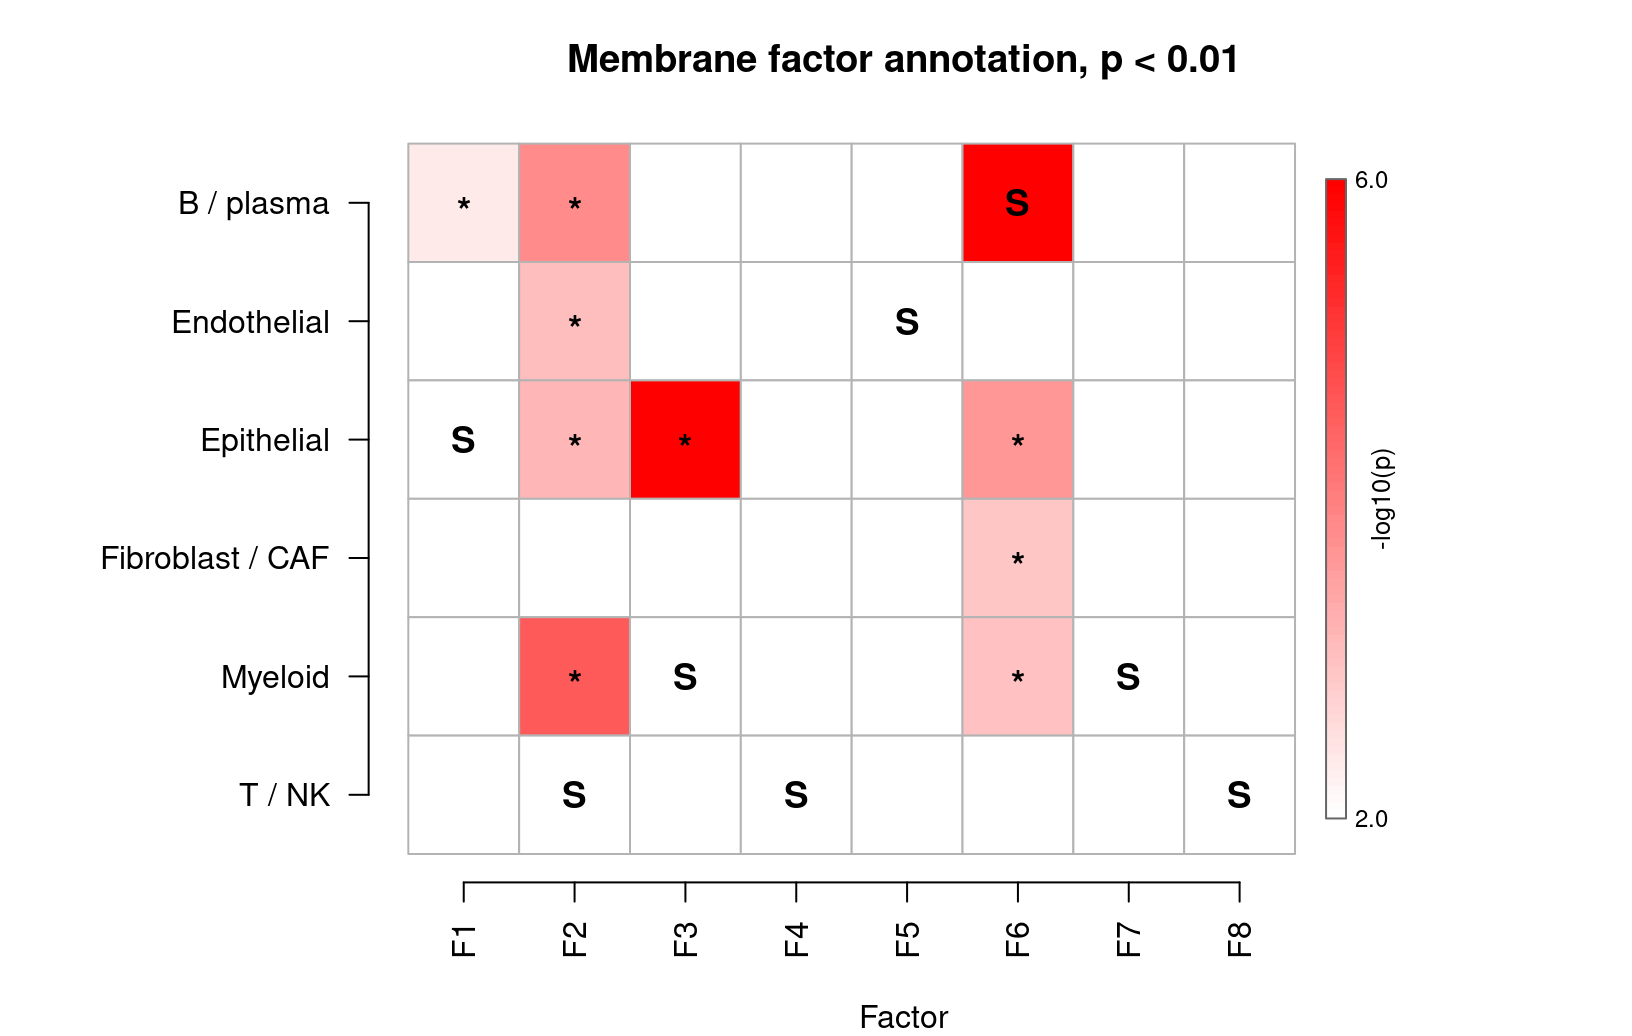

In [ ]:
membrane_score$plot_heatmap(p_thresh = p_thresh)

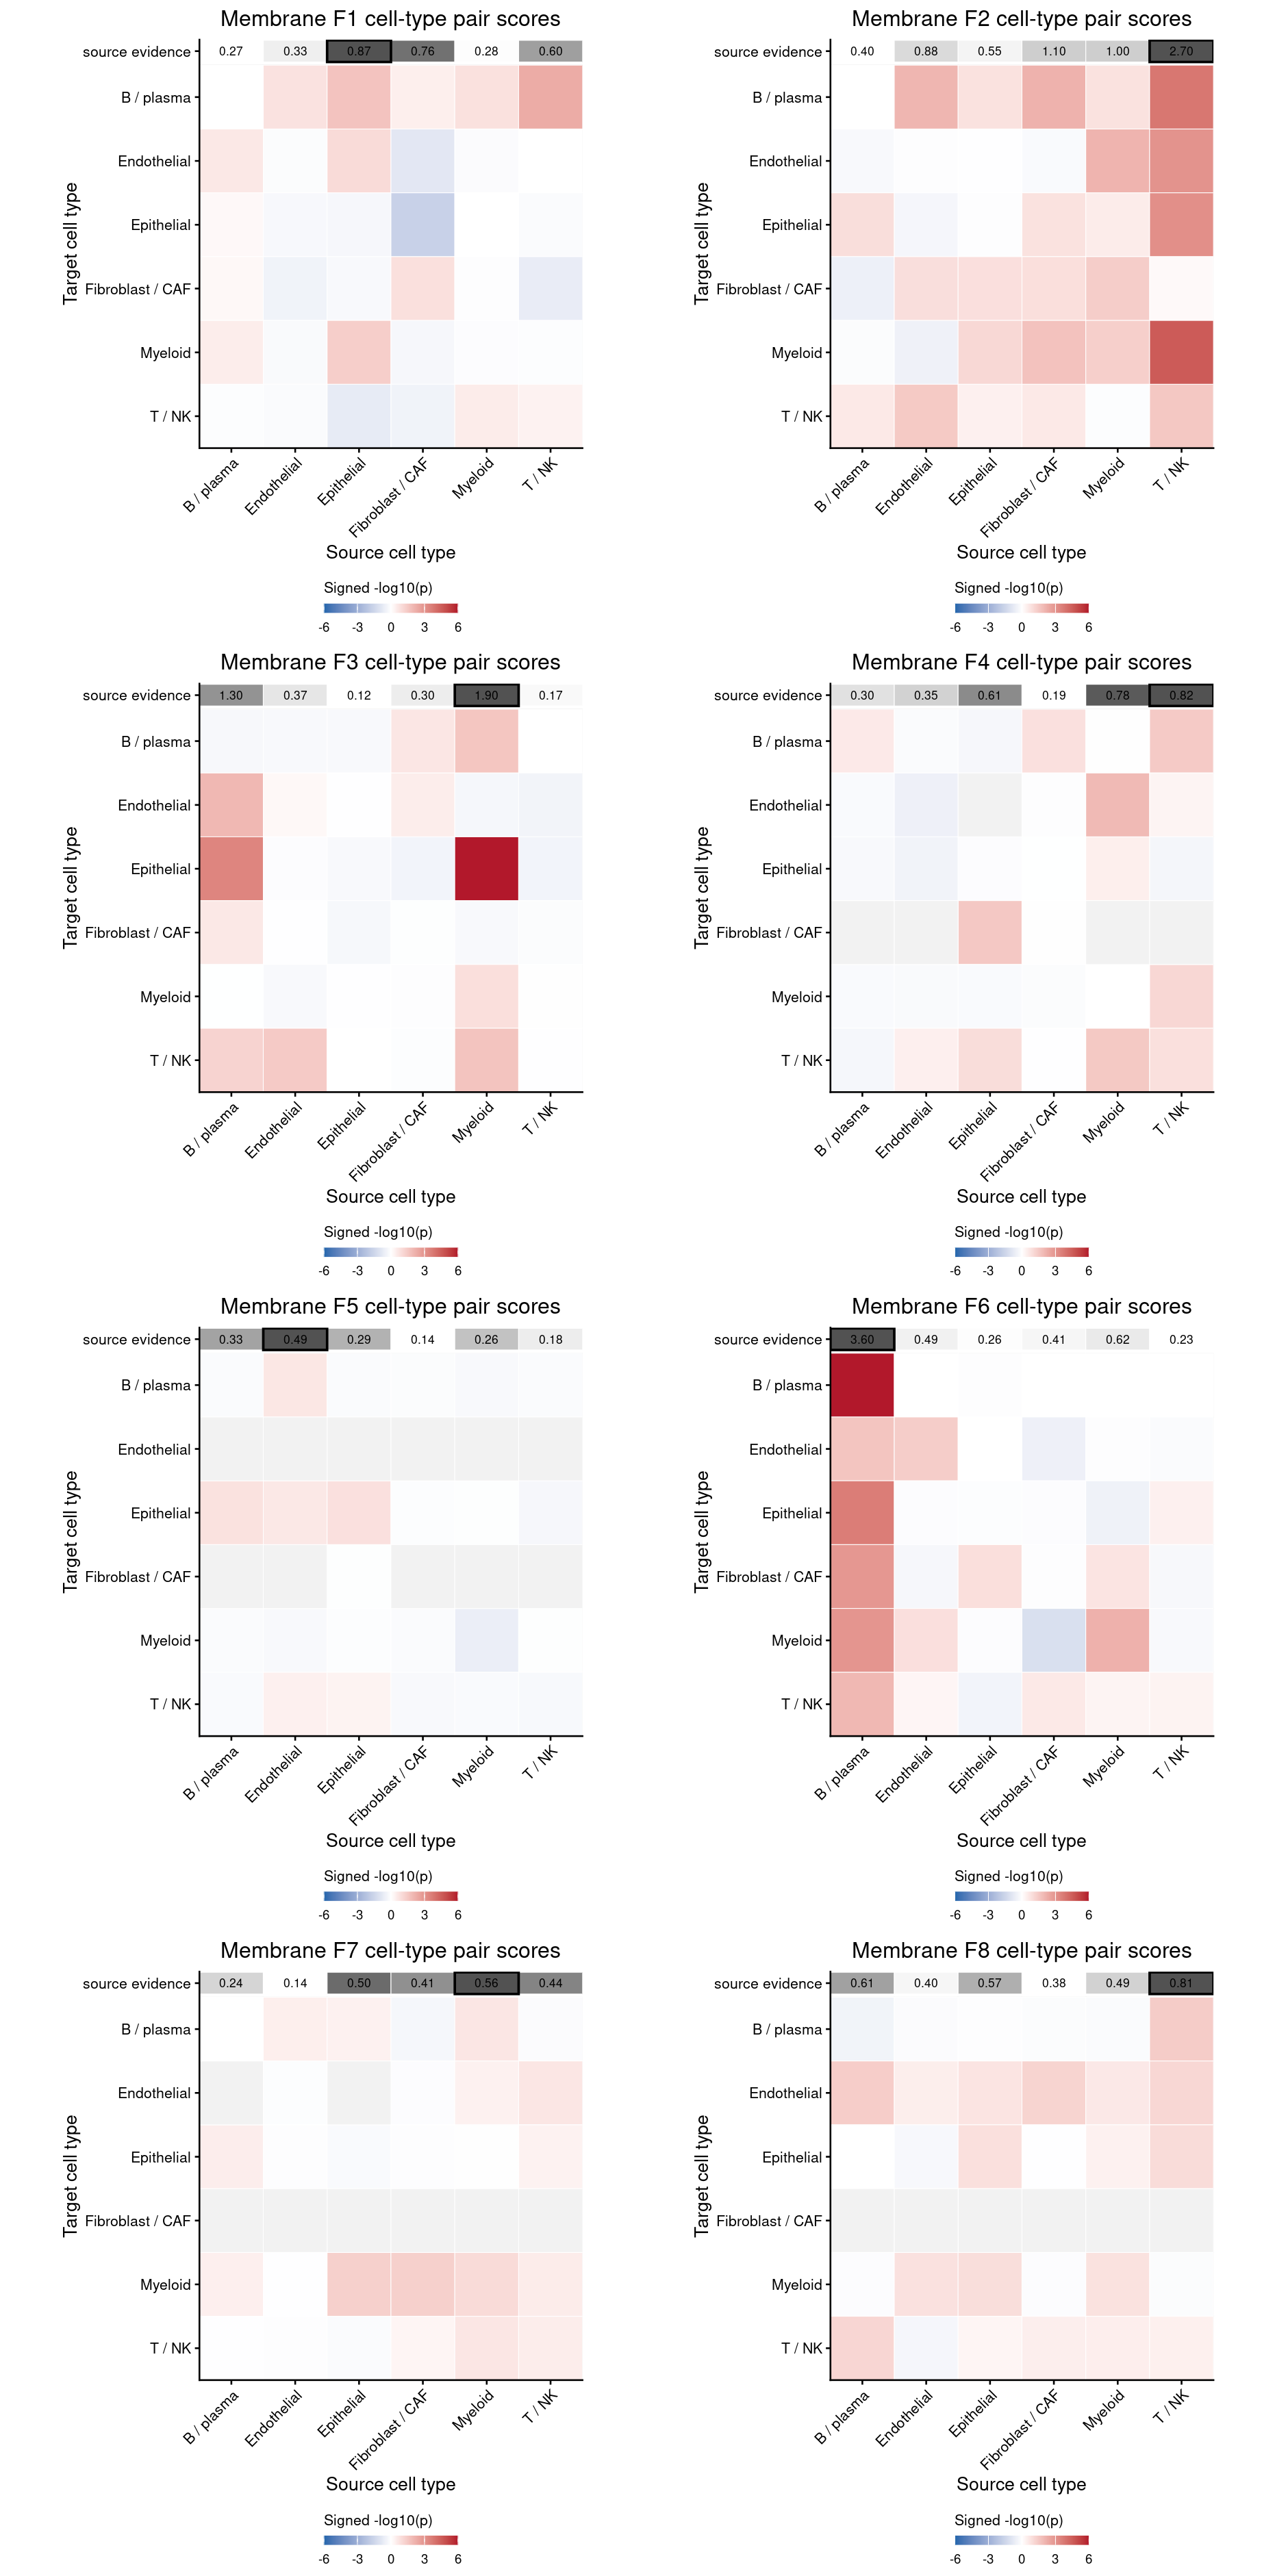

In [ ]:
membrane_score$plot_pairs()

## Example Cells

These examples show the molecule-level interpretation for selected diagnostic
cells before cleanup. The examples are chosen from cells with strong
rule-supported membrane-score evidence. Molecule colors show the native factor
set in blue, the top putative admixture factor in red, and other non-native
factors in orange. Source-marker molecules are drawn slightly larger.

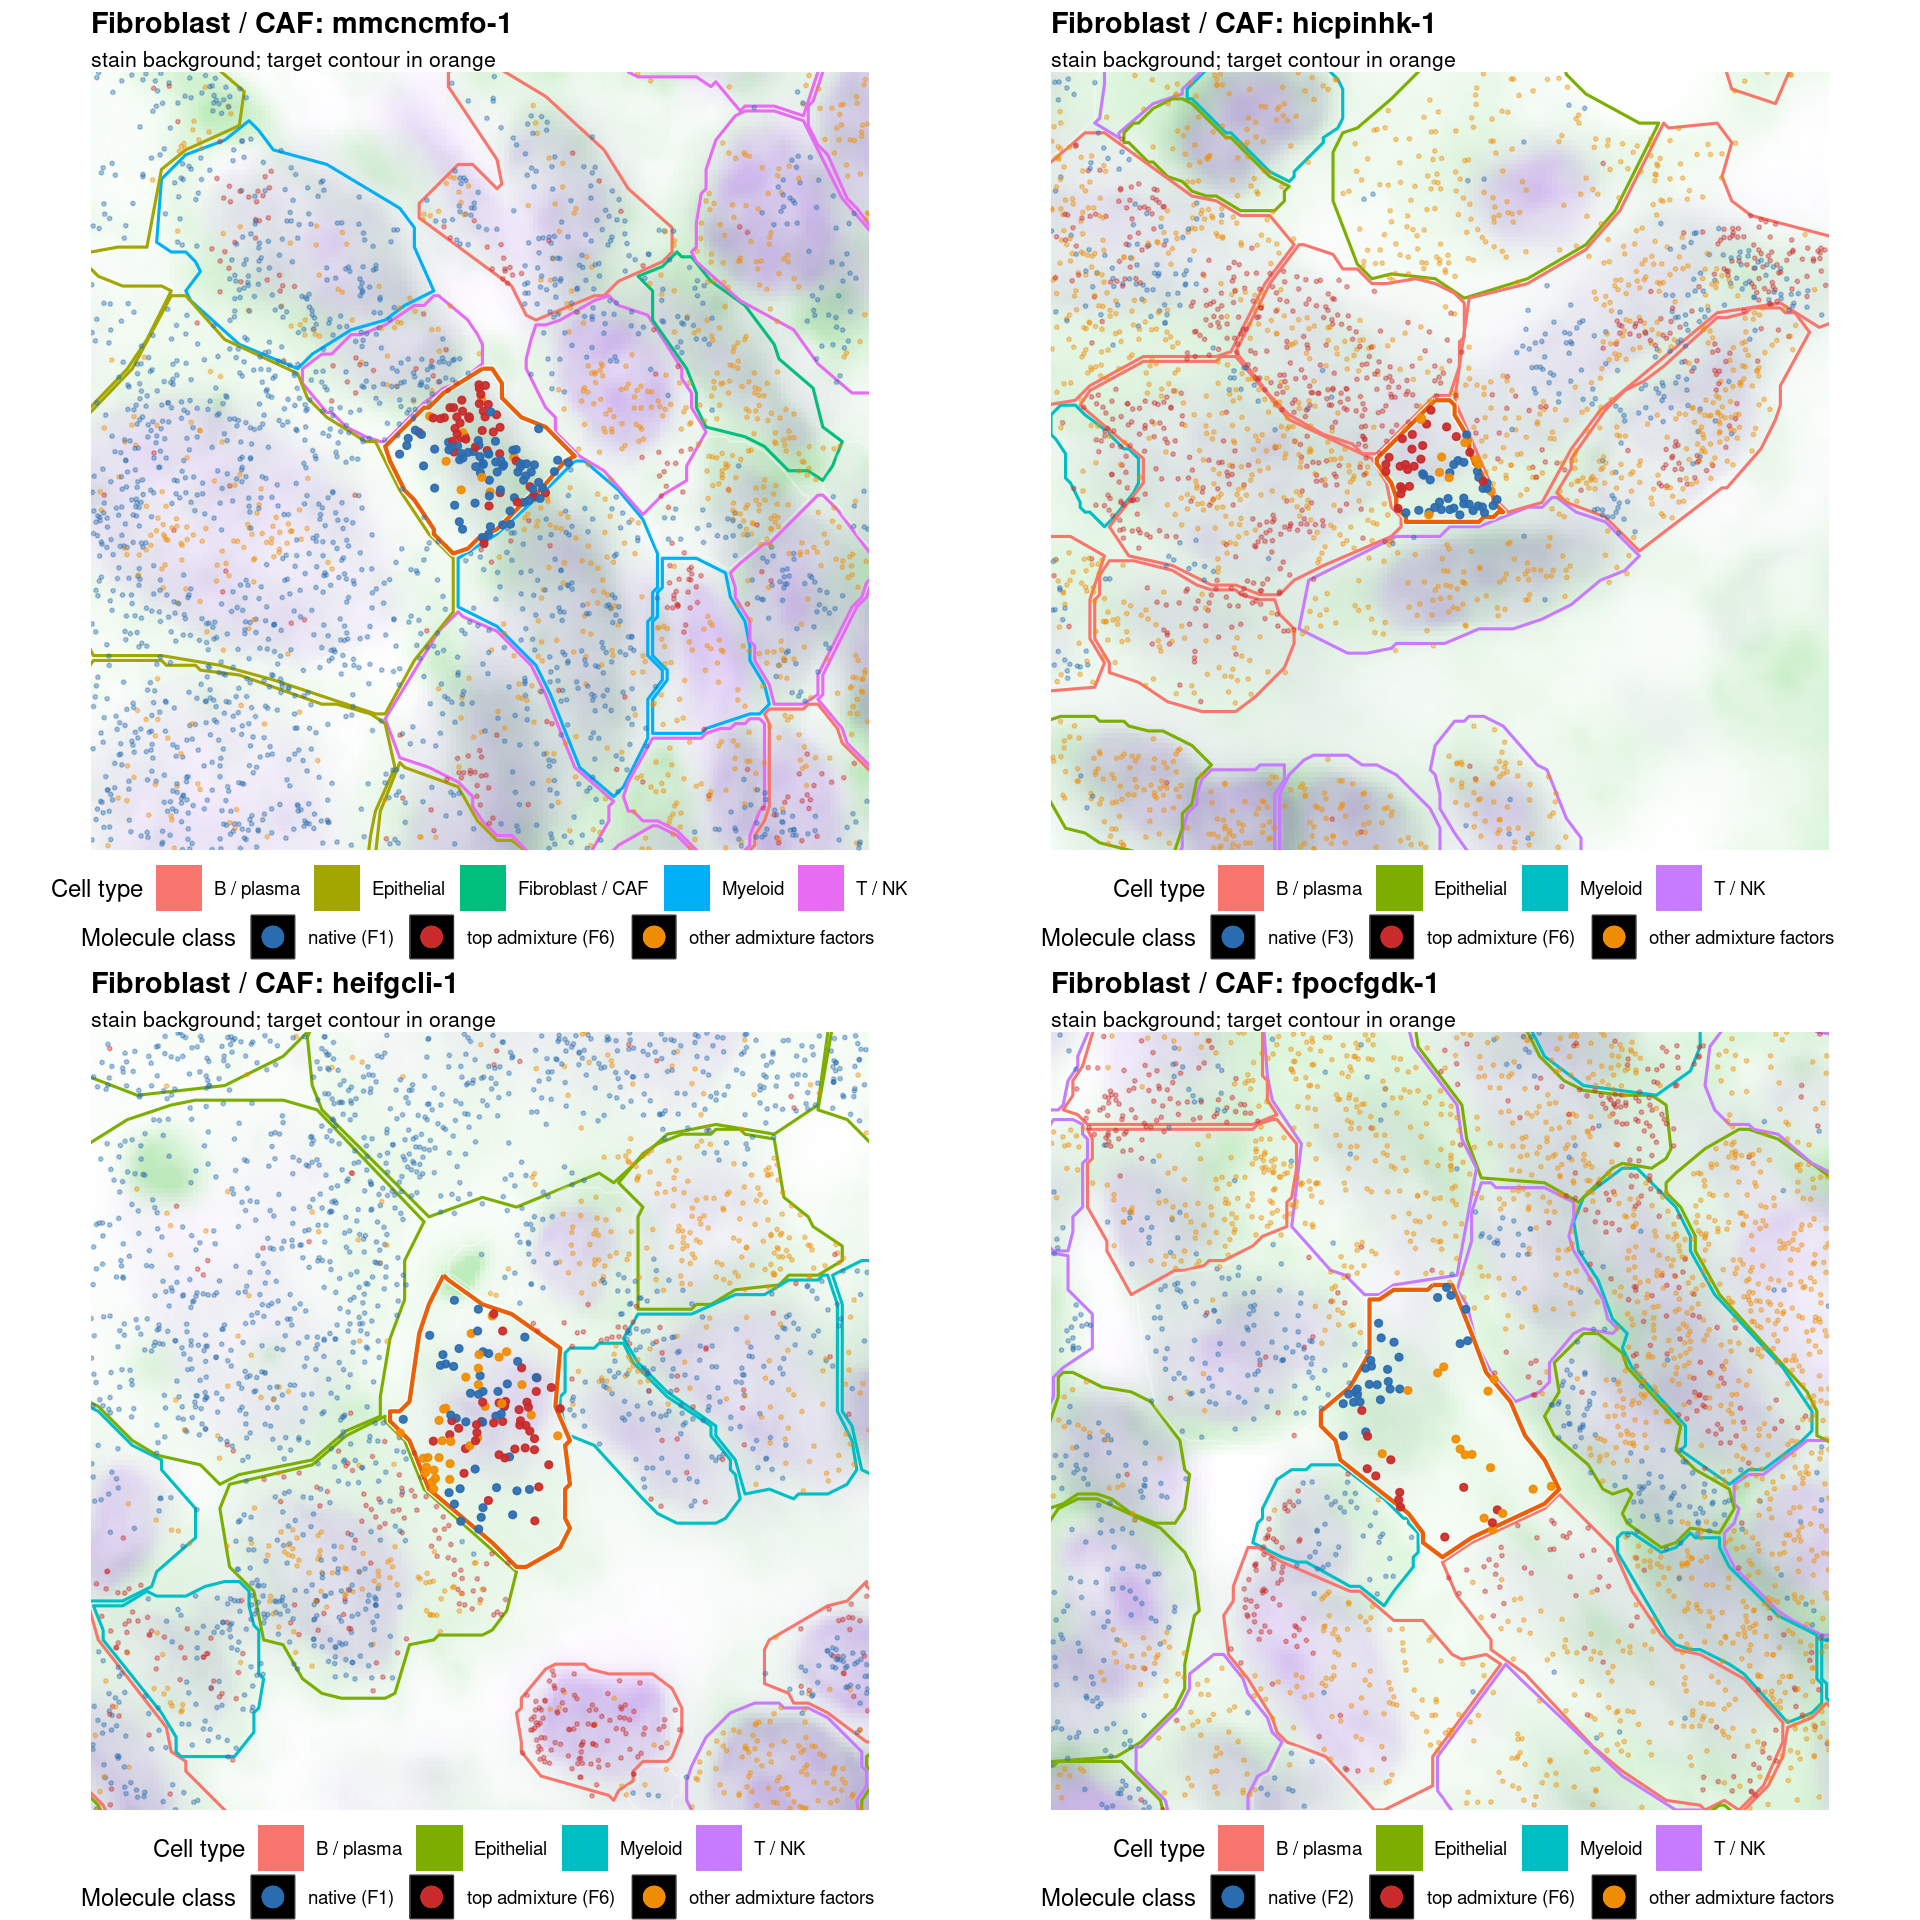

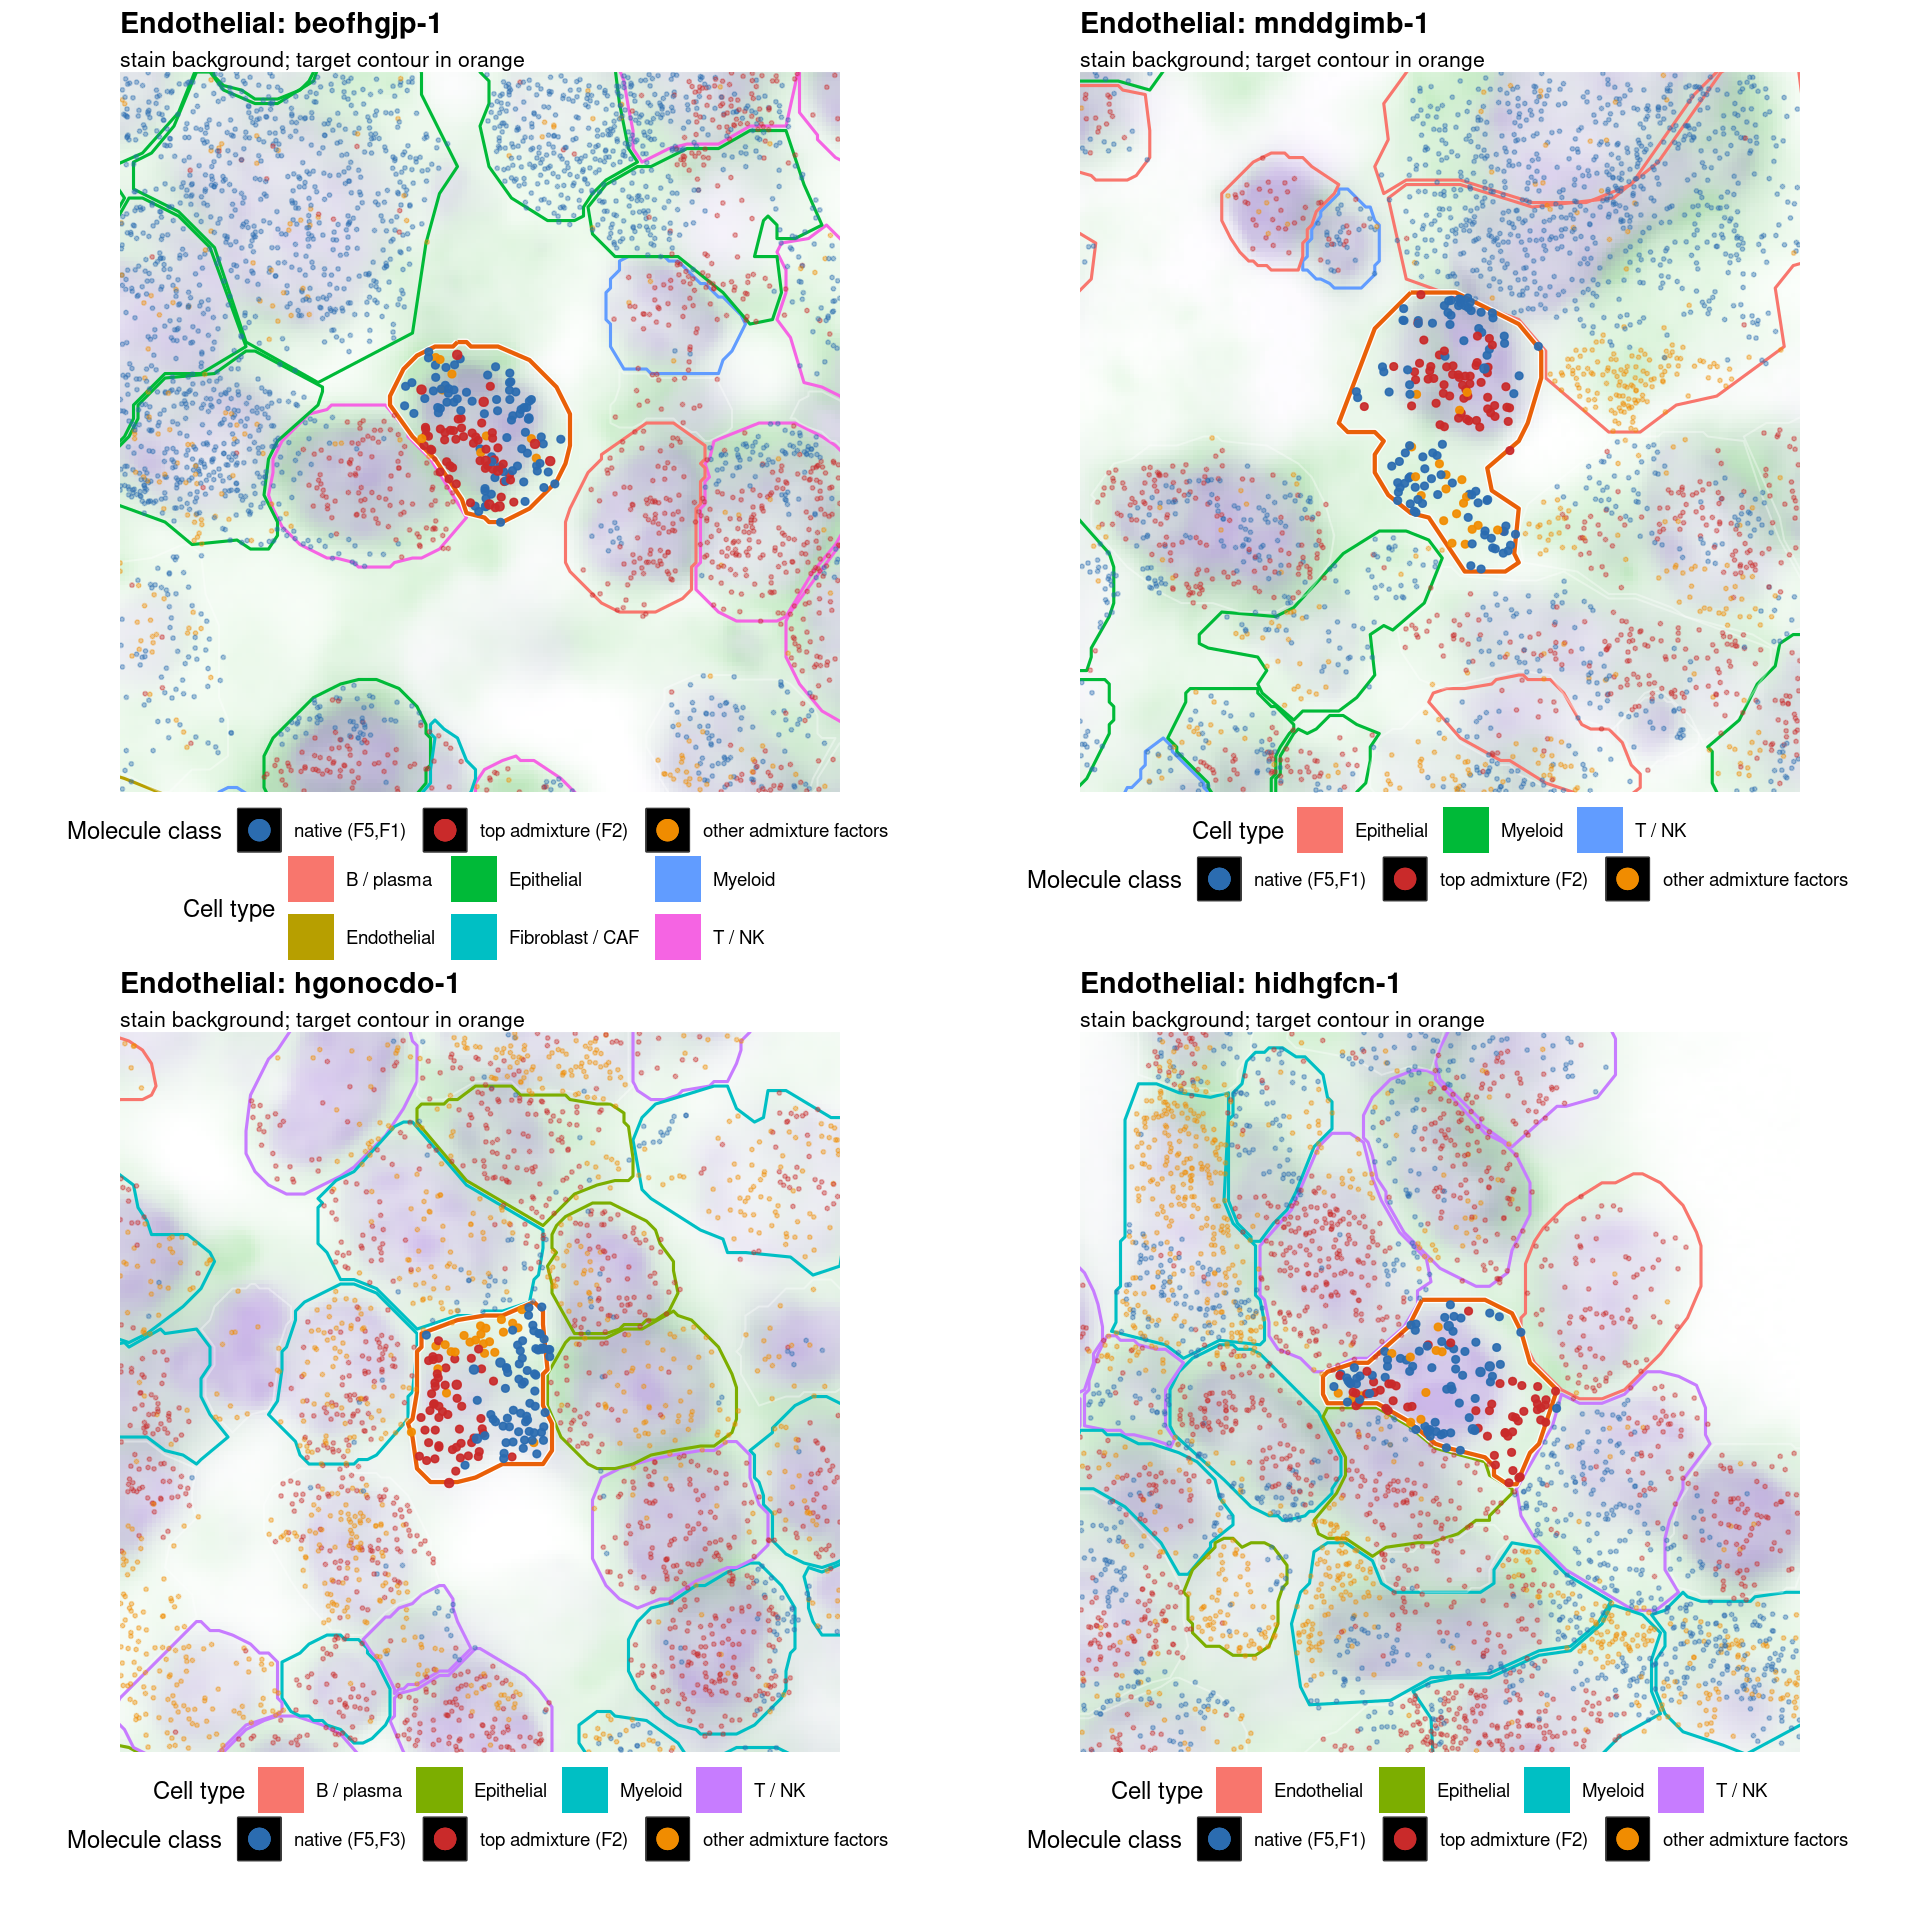

In [ ]:
example_cells <- membrane_score$examples(rules = membrane_rules,
  score_annotation = membrane_annotation, cell_data = cell_spatial,
  targets = diagnostic_cell_types, n_per_target = 4)

for (cell_type in diagnostic_cell_types) {
  type_examples <- example_cells[example_cells$target_cell_type == cell_type, , drop = FALSE]
  print(membrane_score$plot_examples(type_examples,
    score_annotation = membrane_annotation, cell_data = cell_spatial,
    markers = unique(unlist(source_marker_sets)), ncol = 2))
}

## Cleanup Diagnostics

The correction applies all membrane-derived rules; with the default
multi-restart fit it is the molecule-vote ensemble, removing a molecule only
when at least 30% of the independently scored members agree (3 of 10 here).

In [ ]:
membrane_correction <- membrane_score$correct(rules = membrane_rules,
  name = "membrane_clean_p001")
membrane_counts <- membrane_correction$counts()

membrane_correction$summary()

Ensemble correction over 10 members: molecules removed by >= 3 members (vote >= 0.30) are dropped (621,801 molecules).

         cell_type n_cells n_modified_cells fraction_cells_modified
1              all   34541            20531               0.5943951
2       B / plasma    1522             1390               0.9132720
3      Endothelial     815              573               0.7030675
4       Epithelial   14953            14732               0.9852204
5 Fibroblast / CAF     653              417               0.6385911
6          Myeloid    3534             3419               0.9674590
7           T / NK    7130                0               0.0000000
8          unknown    5934                0               0.0000000
  molecules_before molecules_after molecules_removed fraction_molecules_removed
1          8189365         7567564            621801                 0.07592786
2           306036          273035             33001                 0.10783372
3            64415           50501             13914                 0.21600559
4          5963412         5543389            420023                

In [ ]:
membrane_de <- celladmix_de_by_group(membrane_counts, cell_spatial,
  subset_by = "merged_annotation", subsets = diagnostic_cell_types,
  group_by = "domain_label", contrast = c("tumor_epithelial", "immune_rich"))

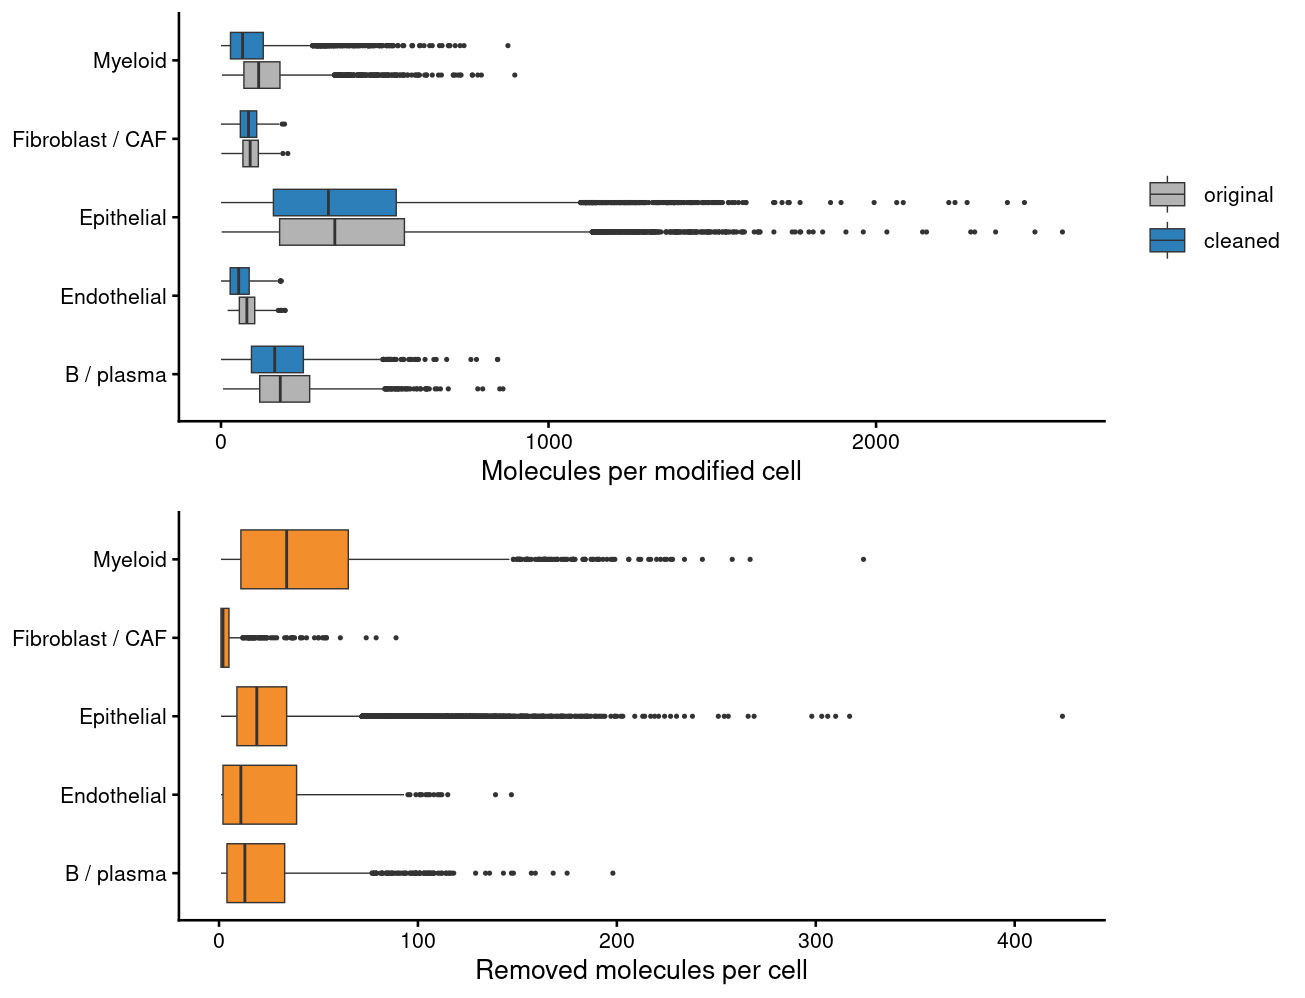

In [ ]:
membrane_correction$plot_removed_molecules()

The audit verifies the cleanup against the same exposure measurements it
used to detect the admixture.

no removal rule covers this pair

removal rule covers this pair

removal rule covers this pair

$detected_pairs
[1] 13

$estimated_admixed_molecules
[1] 706403

$leakage_removed_overall
[1] 0.7233465

$median_pair_sensitivity
[1] 0.1166828

$own_marker_false_removal
[1] 0.00313466

$worst_false_removal
[1] "Endothelial"

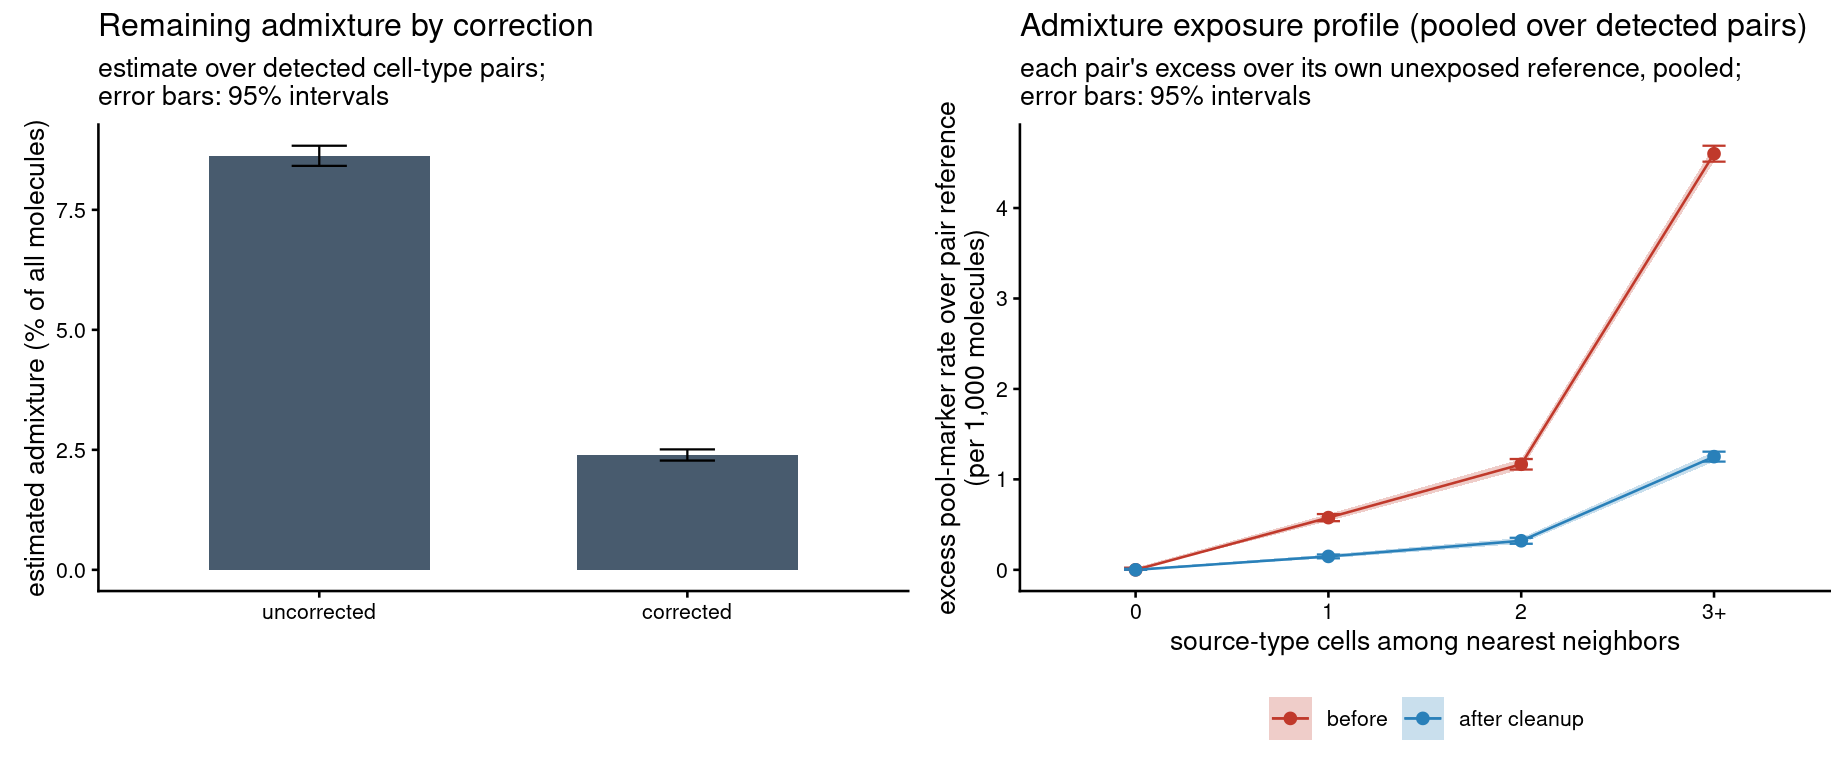

In [ ]:
report <- audit$evaluate(membrane_correction)
report$summary()

cowplot::plot_grid(
  audit$plot_remaining(list(corrected = membrane_correction)),
  audit$plot_exposure(correction = membrane_correction),
  ncol = 2, align = "hv", axis = "tblr")

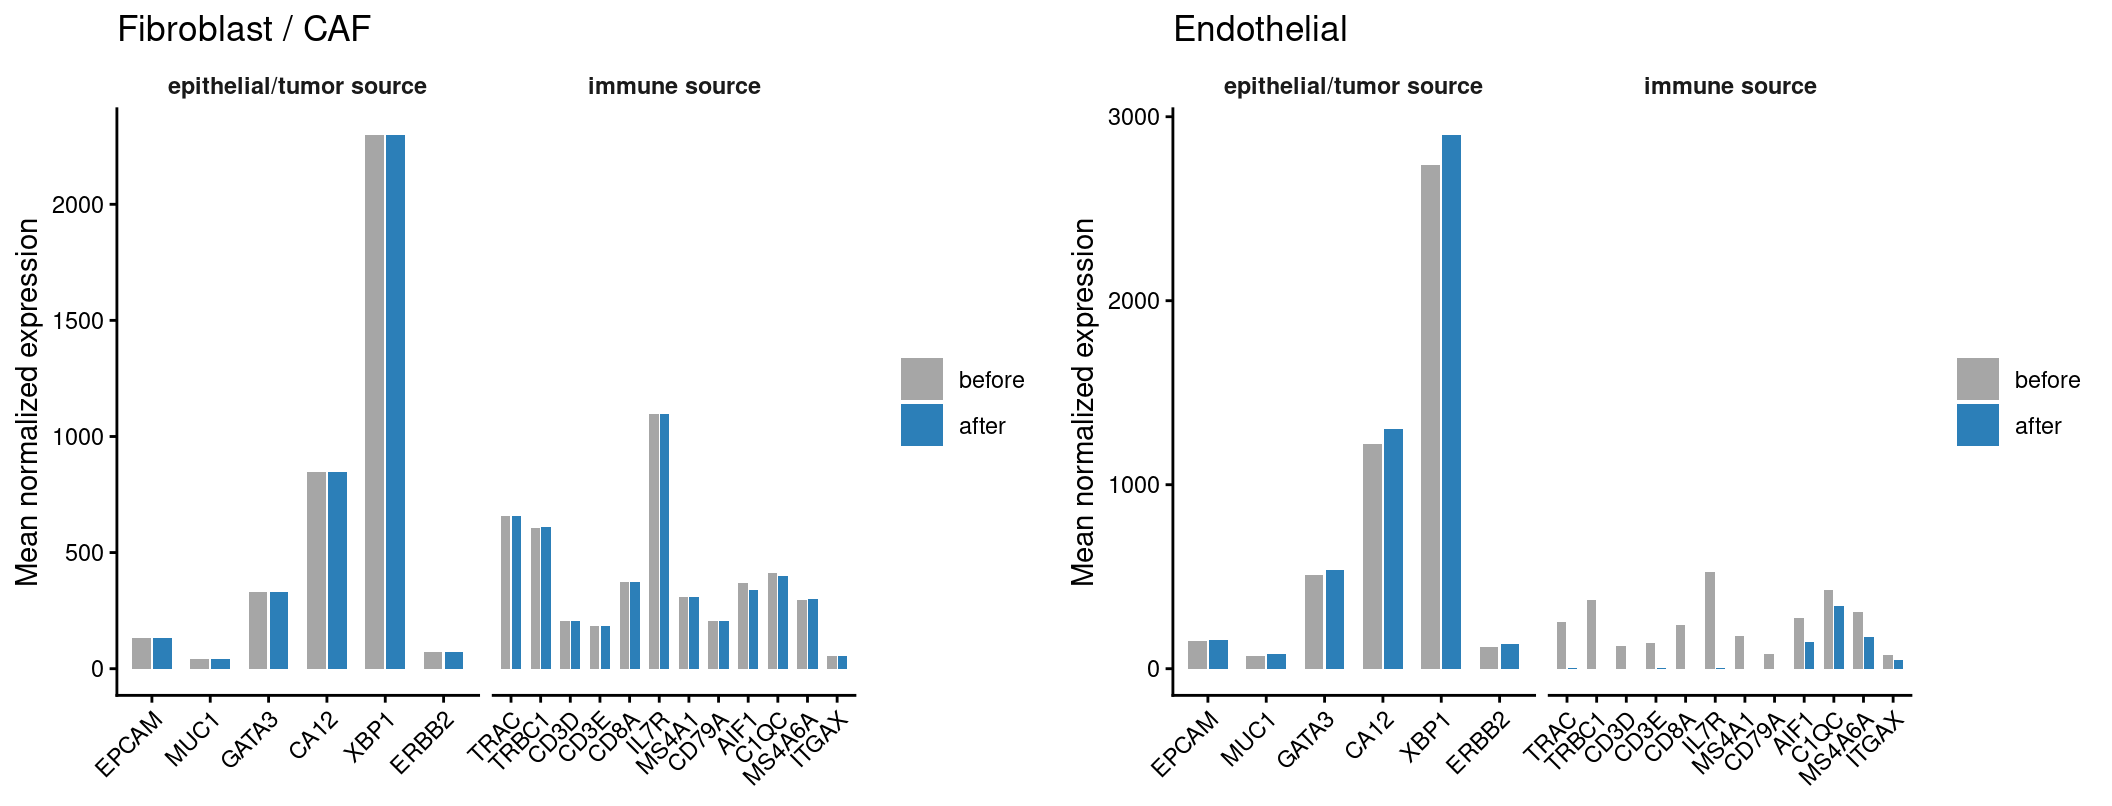

In [ ]:
plots <- lapply(diagnostic_cell_types, function(cell_type) {
  cells <- cell_spatial$cell_id[cell_spatial$merged_annotation == cell_type]
  celladmix_plot_marker_expression(original_counts, membrane_counts,
    cells = cells, markers = source_marker_sets) +
    ggtitle(cell_type)
})
cowplot::plot_grid(plotlist = plots, ncol = length(plots), align = "hv", axis = "tblr")

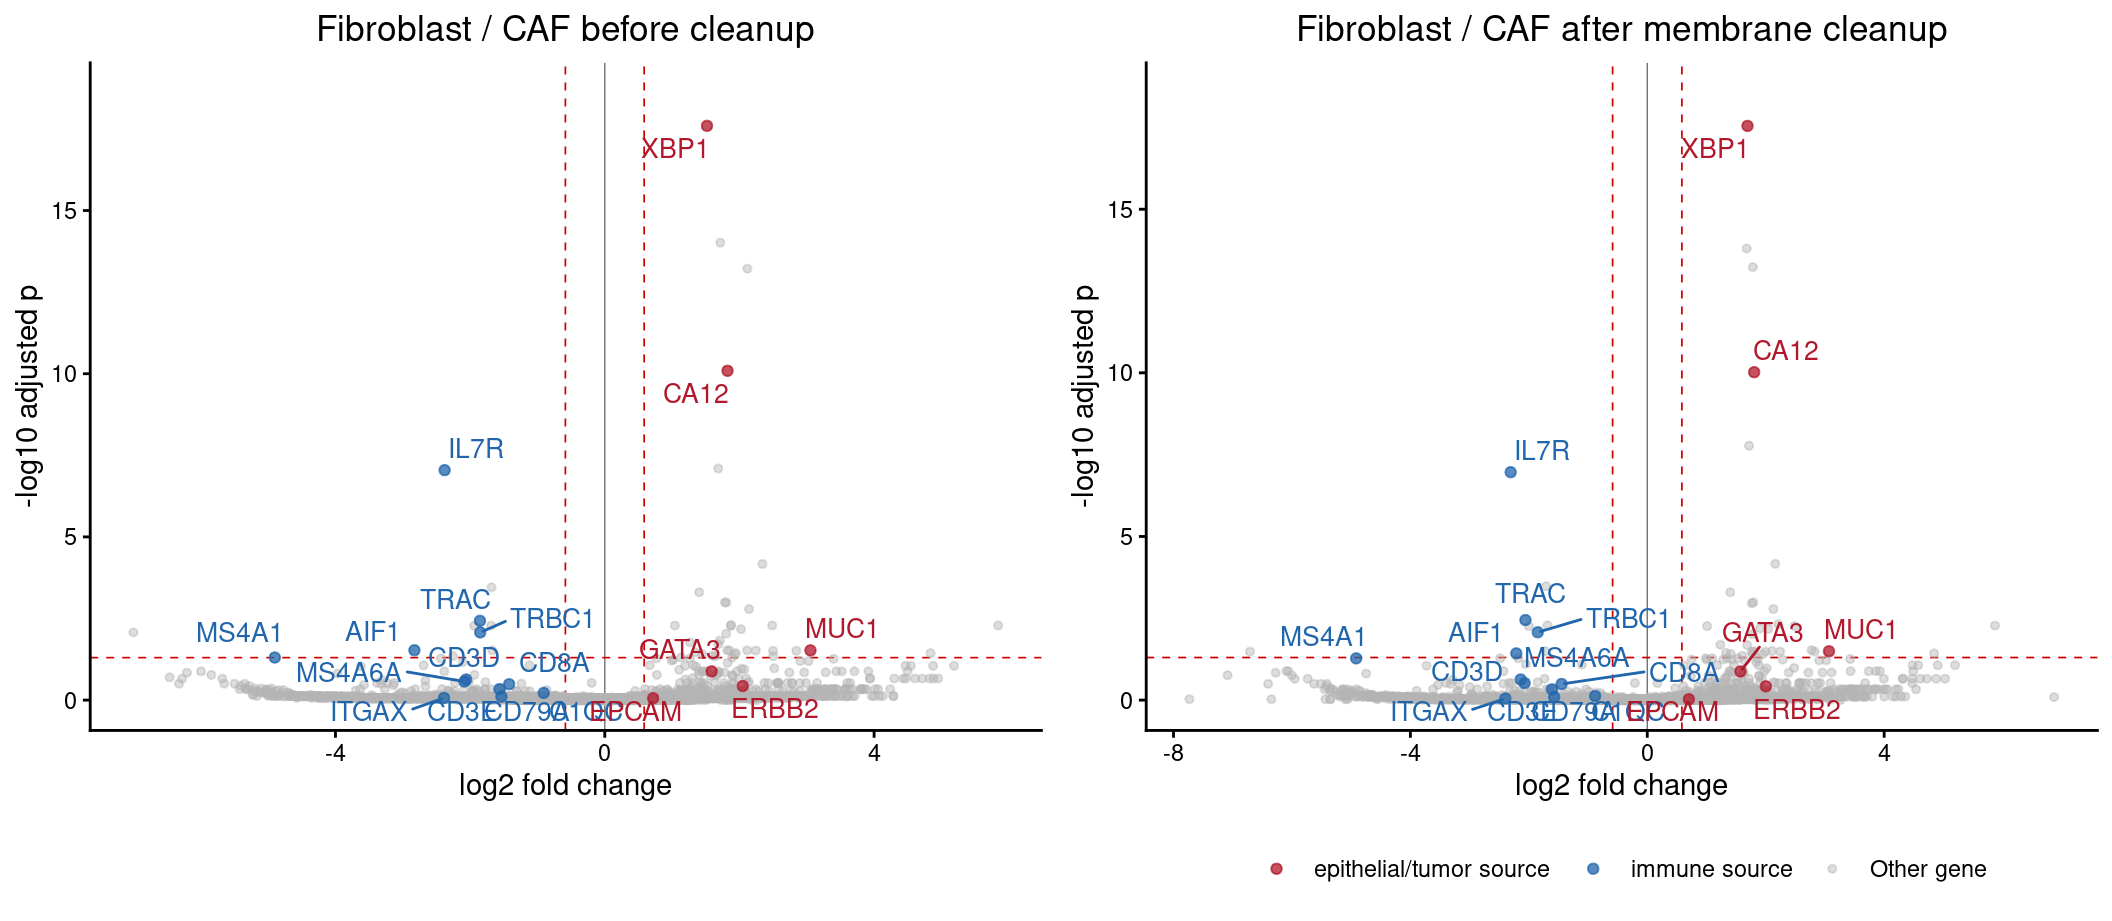

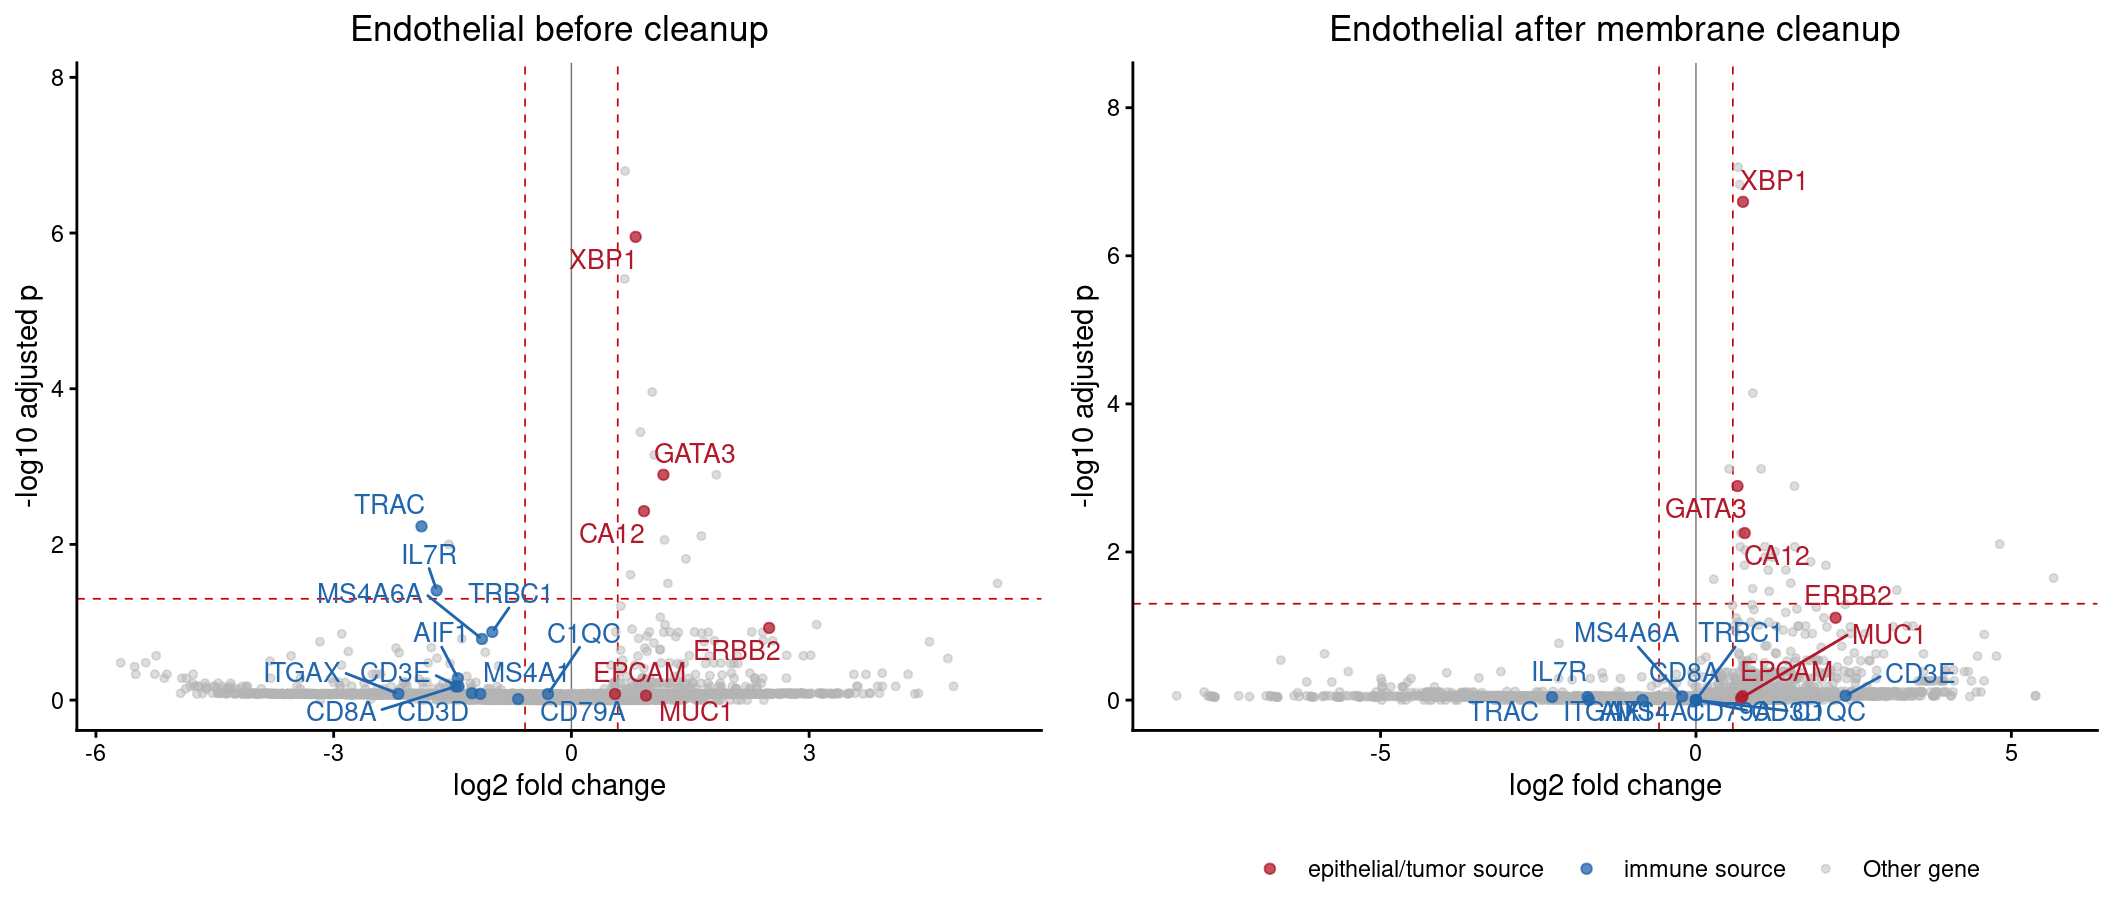

In [ ]:
for (target_type in diagnostic_cell_types) {
  p_before <- celladmix_plot_volcano(diagnostic_de_original[[target_type]],
    markers = source_marker_sets, title = paste(target_type, "before cleanup")) +
    theme(legend.position = "none")
  p_after <- celladmix_plot_volcano(membrane_de[[target_type]],
    markers = source_marker_sets, title = paste(target_type, "after membrane cleanup"))
  print(cowplot::plot_grid(plotlist = list(p_before, p_after),
    ncol = 2, align = "hv", axis = "tblr"))
}

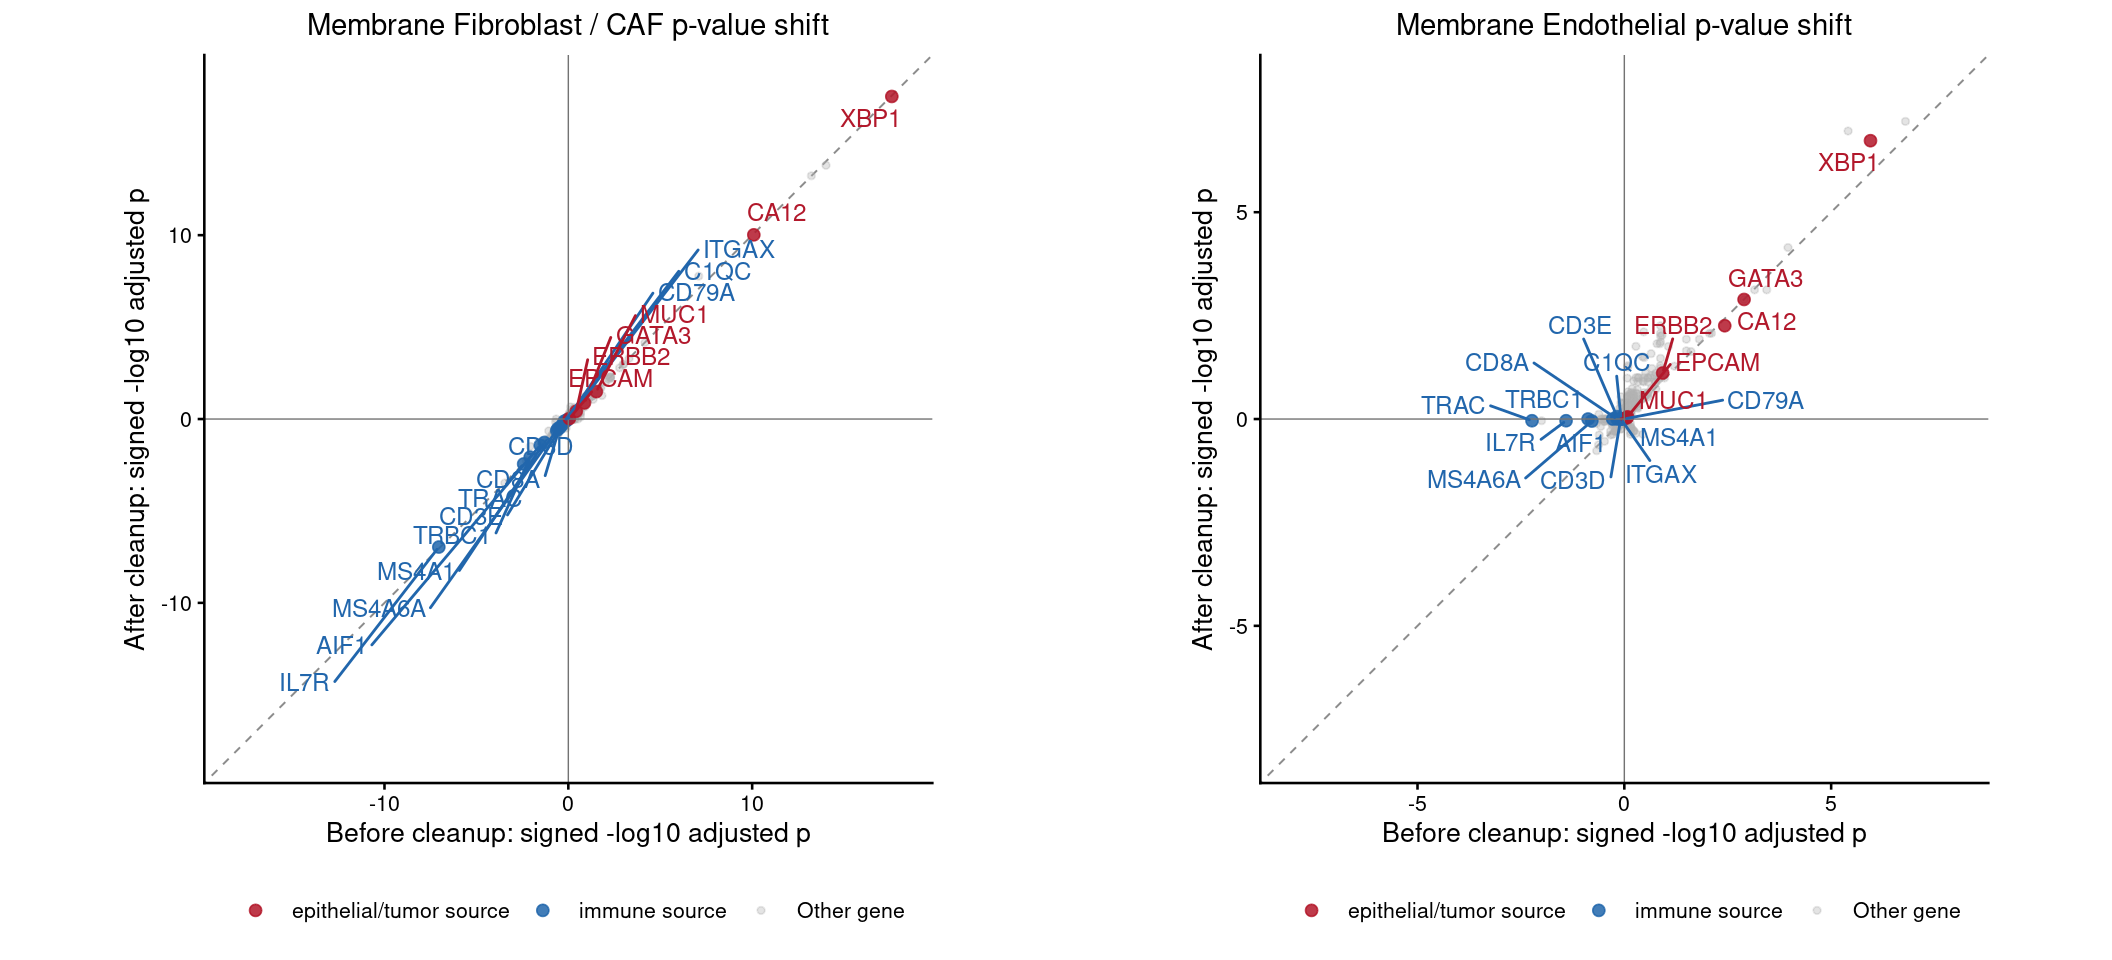

In [ ]:
plots <- lapply(diagnostic_cell_types, function(target_type) {
  celladmix_plot_de_shift(diagnostic_de_original[[target_type]], membrane_de[[target_type]],
    markers = source_marker_sets, title = paste("Membrane", target_type, "p-value shift"))
})
cowplot::plot_grid(plotlist = plots, ncol = length(plots), align = "hv", axis = "tblr")

## Cell-State UMAP Before and After Cleanup

In [ ]:
state_cells_max <- NULL
original_state_all <- ds$cell_state_umap(cells_max = state_cells_max,
  min_molecules = 30, min_genes = 15, verbose = TRUE)
corrected_state_all <- membrane_correction$cell_state_umap(cells_max = state_cells_max,
  min_molecules = 30, min_genes = 15, verbose = TRUE)
cell_type_levels <- sort(unique(cell_annotation))
cell_type_palette <- setNames(grDevices::hcl.colors(length(cell_type_levels), "Dark 3"),
  cell_type_levels)
original_state_all$cell_type <- factor(original_state_all$cell_type, levels = cell_type_levels)
corrected_state_all$cell_type <- factor(corrected_state_all$cell_type, levels = cell_type_levels)

shared_state_cells <- intersect(original_state_all$cell_id, corrected_state_all$cell_id)
original_state <- original_state_all[original_state_all$cell_id %in% shared_state_cells, , drop = FALSE]
corrected_state <- corrected_state_all[corrected_state_all$cell_id %in% shared_state_cells, , drop = FALSE]
original_state$cell_type <- factor(original_state$cell_type, levels = cell_type_levels)
corrected_state$cell_type <- factor(corrected_state$cell_type, levels = cell_type_levels)

state_cell_retention <- rbind(
  data.frame(panel = "original eligible", as.data.frame(table(original_state_all$cell_type))),
  data.frame(panel = "corrected eligible", as.data.frame(table(corrected_state_all$cell_type))),
  data.frame(panel = "plotted common cells", as.data.frame(table(original_state$cell_type)))
)
names(state_cell_retention) <- c("panel", "cell_type", "cells")
state_cell_retention

[INFO 17:50:16 +0.003s] Reused compatible Xenium input store (0.000s)
[INFO 17:50:16 +0.003s] Built Xenium input store: 8189365 molecules, 34541 cells (0.003s)
[INFO 17:50:16 +0.249s] Loaded input-store cell-gene counts: 34541 cells (0.249s)
[INFO 17:50:16 +0.263s] Indexed cell counts: 31642 eligible cells (min_molecules=30, min_genes=15) (0.013s)
[INFO 17:50:16 +0.263s] Selected clustering cells: 31642 cells (0.000s)
[INFO 17:50:16 +0.380s] Loaded sparse cell-gene counts: 6011201 non-zero entries (0.117s)
[INFO 17:50:16 +0.545s] Selected variable genes: 1000 genes (0.165s)
[INFO 17:50:17 +1.048s] Materialized dense clustering matrix: 1000 x 31642 (0.503s)
[INFO 17:50:23 +7.702s] Computed cell PCA: 30 x 31642 (6.655s)
[INFO 17:50:25 +9.545s] Built HNSW cell KNN graph: 474630 directed edges using 10 thread(s); reusing 15 cosine-distance neighbors for UMAP (1.843s)
[INFO 17:50:25 +9.732s] Ran Louvain clustering (0.187s)
[INFO 17:50:26 +10.032s] Initialized UMAP layout (0.299s)
[INFO 17:5

[INFO 17:50:57 +2.040s] Loaded run cell-gene counts: 34541 cells (2.040s)
[INFO 17:50:57 +2.053s] Indexed cell counts: 29049 eligible cells (min_molecules=30, min_genes=15) (0.012s)
[INFO 17:50:57 +2.053s] Selected clustering cells: 29049 cells (0.000s)
[INFO 17:50:57 +2.115s] Loaded sparse cell-gene counts: 5448449 non-zero entries (0.062s)
[INFO 17:50:57 +2.272s] Selected variable genes: 1000 genes (0.157s)
[INFO 17:50:57 +2.765s] Materialized dense clustering matrix: 1000 x 29049 (0.494s)
[INFO 17:51:04 +9.600s] Computed cell PCA: 30 x 29049 (6.834s)
[INFO 17:51:06 +11.281s] Built HNSW cell KNN graph: 435735 directed edges using 10 thread(s); reusing 15 cosine-distance neighbors for UMAP (1.681s)
[INFO 17:51:07 +11.862s] Ran Louvain clustering (0.581s)
[INFO 17:51:07 +12.130s] Initialized UMAP layout (0.267s)
[INFO 17:51:38 +43.283s] Optimized UMAP layout with parallel optimization (31.154s)
[INFO 17:51:38 +43.284s] Computed cell UMAP (31.422s)
[INFO 17:51:38 +43.305s] Assembled cel

                  panel        cell_type cells
1     original eligible       B / plasma  1512
2     original eligible      Endothelial   810
3     original eligible       Epithelial 14928
4     original eligible Fibroblast / CAF   648
5     original eligible          Myeloid  3509
6     original eligible           T / NK  7094
7    corrected eligible       B / plasma  1356
8    corrected eligible      Endothelial   657
9    corrected eligible       Epithelial 13509
10   corrected eligible Fibroblast / CAF   629
11   corrected eligible          Myeloid  2663
12   corrected eligible           T / NK  7094
13 plotted common cells       B / plasma  1356
14 plotted common cells      Endothelial   657
15 plotted common cells       Epithelial 13509
16 plotted common cells Fibroblast / CAF   629
17 plotted common cells          Myeloid  2663
18 plotted common cells           T / NK  7094

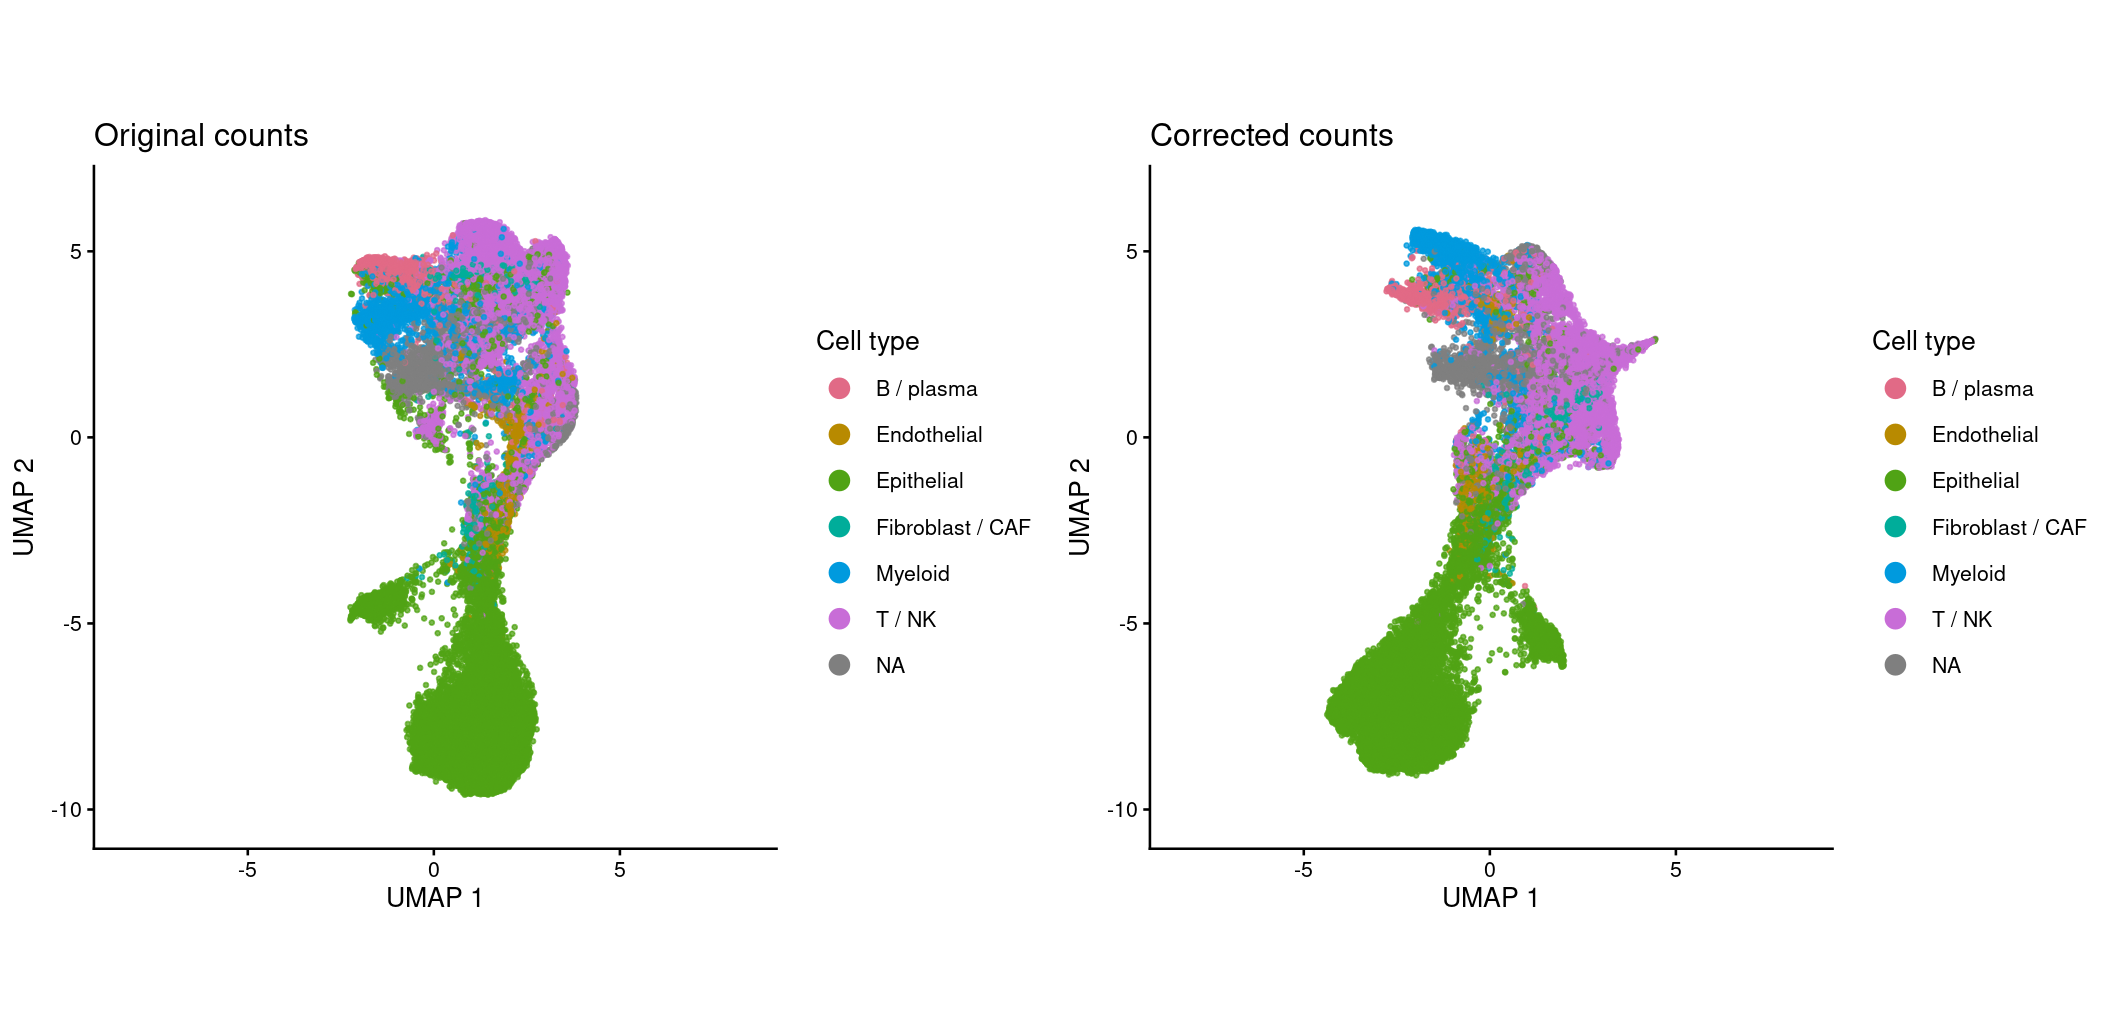

In [ ]:
state_umap_limits <- function(...) {
  frames <- list(...)
  x <- unlist(lapply(frames, `[[`, "umap_1"))
  y <- unlist(lapply(frames, `[[`, "umap_2"))
  span <- max(diff(range(x, na.rm = TRUE)), diff(range(y, na.rm = TRUE)))
  xmid <- mean(range(x, na.rm = TRUE))
  ymid <- mean(range(y, na.rm = TRUE))
  pad <- span * 0.04
  list(xlim = xmid + c(-1, 1) * (span / 2 + pad),
    ylim = ymid + c(-1, 1) * (span / 2 + pad))
}

plot_state_umap <- function(df, title, limits) {
  ggplot(df, aes(umap_1, umap_2, color = cell_type)) +
    geom_point(size = 0.55, alpha = 0.75) +
    coord_equal(xlim = limits$xlim, ylim = limits$ylim) +
    scale_color_manual(values = cell_type_palette, drop = FALSE) +
    labs(title = title, x = "UMAP 1", y = "UMAP 2", color = "Cell type") +
    theme_classic(base_size = 10) +
    guides(color = guide_legend(override.aes = list(size = 3.2, alpha = 1))) +
    theme(legend.position = "right")
}

limits <- state_umap_limits(original_state, corrected_state)
cowplot::plot_grid(plotlist = list(
  plot_state_umap(original_state, "Original counts", limits),
  plot_state_umap(corrected_state, "Corrected counts", limits)
), ncol = 2, align = "hv", axis = "tblr")